In [29]:
import torch as nn 
import torch.nn as nn 
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import SGD
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd 
import numpy as np 

import os

pd.set_option('display.max_columns', None)  # Show all columns in DataFrame display

In [30]:
LETTUCE_FW_DATA_PATH = '../Data/RawData/Trial_2_Lettuce_FW_Data_Per_Plant.csv'
SENSOR_DATA_PATH = '../Data/CleanData/Trial_2_Neural_Network_Sensor_Data.csv'

def load_lettuce_fw_data(path=LETTUCE_FW_DATA_PATH):

    df = pd.read_csv(path)
    return df

def load_sensor_data(path=SENSOR_DATA_PATH):
    """
    Loads sensor time series data. Still needs ot be imputed and averaged to merge with lettuce data.
    """

    df = pd.read_csv(path)
    return df

# Neural Network 5 (model5)
* Preprocessing: Standardized features 
* Model: Basic feedforward NN with 1 hidden layer (32 neurons, ReLU activation)
* Adam optimizer, MSE loss
* Hyperparameters:
  * Adam optimizer
  * MSE Loss 
  * Hidden layer size: 32
  * Learning rate: 0.01
  * Epochs: 100
  * Used 5-fold cross-validation to select hyperparameters
* Evaluation: Final test loss (MSE and RMSE)

Features: 
  * carbon_dioxide
  * temp_env
  * humidity
  * pressure
  * electrical_conductivity
  * volume
  * temp_nutr
  * volume_flow_rate


Target: total_fresh_weight_g

In [31]:
lettuce_fw_data = load_lettuce_fw_data()
# extract features that will be joined with sensor data 

df_lettuce_fw = lettuce_fw_data[['Day', 'Plant-ID', 'Total Fresh Weight (g)']]
df_lettuce_fw.rename(columns={'Day':'day', 'Plant-ID':'plant_id', 'Total Fresh Weight (g)': 'total_fresh_weight_g'}, inplace=True)
df_lettuce_fw.dropna(how='all', inplace=True)
df_lettuce_fw

/var/folders/b2/dv4s0x994dz37s4d7fv56q8r0000gn/T/ipykernel_79582/2601978036.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_lettuce_fw.rename(columns={'Day':'day', 'Plant-ID':'plant_id', 'Total Fresh Weight (g)': 'total_fresh_weight_g'}, inplace=True)
/var/folders/b2/dv4s0x994dz37s4d7fv56q8r0000gn/T/ipykernel_79582/2601978036.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_lettuce_fw.dropna(how='all', inplace=True)


,day,plant_id,total_fresh_weight_g
0,0.0,6.0,29.1
1,0.0,4.0,29.3
2,0.0,9.0,29.6
3,0.0,1.0,29.7
4,0.0,8.0,29.8
...,...,...,...
82,28.0,2.0,206.0
83,28.0,4.0,208.0
84,28.0,6.0,211.0
85,28.0,8.0,215.0


In [ ]:
import pandas as pd
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
sensor_data = load_sensor_data()

def knn_impute_sensor_data(sensor_data, n_neighbors=1):
    """
    Uses knn regression to impute missing values in the dataframe.
    Imputes in order from columns with theleast missing values to most missing values to increase
    the accuracy of the knn regression by using as much observed data as possible for each imputation.

    Only imputes missing values using observed values from other features within the same day period to avoid data leakage. 
    """
    
    numeric_features = sensor_data.columns.drop(['time_stamp', 'day_period']) # features to use for imputation
    sensor_data_imputed = sensor_data.copy()


    for day in sensor_data['day_period'].unique():

        # isolate data for current day period
        day_mask = sensor_data['day_period'] == day
        sensor_data_day = sensor_data.loc[day_mask].copy()

        # standardize within current day period
        scaler = StandardScaler()
        sensor_data_day[numeric_features] = scaler.fit_transform(sensor_data_day[numeric_features])
        sensor_data_imputed.loc[day_mask, numeric_features] = sensor_data_day[numeric_features]

        # initialize models
        knn_regressor = KNeighborsRegressor(n_neighbors=n_neighbors, weights='distance')
        knn_imputer = KNNImputer(n_neighbors=n_neighbors, weights='distance')

        # sort features by missingness (within this day only)
        missing_features_sorted = (
            sensor_data_day[numeric_features]
            .isna()
            .sum()
            .sort_values(ascending=True)
            .index
            .to_list()
        )


    
    
        for feature_to_impute in missing_features_sorted:
            features_to_fit_on = [feat for feat in missing_features_sorted if feat != feature_to_impute]

            # impute for regression
            temp_df = sensor_data_day.copy()

            observed_mask = temp_df[feature_to_impute].notna()
            missing_mask = temp_df[feature_to_impute].isna()

            # fill other features' missing values to prepare dataframe for knn regression
            temp_df[features_to_fit_on]= knn_imputer.fit_transform(temp_df[features_to_fit_on])
            
            # fit knn regressor on observe values for the current feature 
            X_train = temp_df.loc[observed_mask, features_to_fit_on] # records to train regressor on (only observed values for feature we are imputing)
            y_train = temp_df.loc[observed_mask, feature_to_impute] # target variable for regressor (observed values for feature we are imputing)

            X_missing = temp_df.loc[missing_mask, features_to_fit_on] # records to predict on (only missing values for feature we are imputing)

            if X_missing.shape[0] == 0:
                continue
            knn_regressor.fit(X_train, y_train)

            # impute data with knn regressor
            sensor_data_day.loc[missing_mask,feature_to_impute] = knn_regressor.predict(X_missing)

        # convert back to original scale
        sensor_data_day[numeric_features] = scaler.inverse_transform(sensor_data_day[numeric_features])
        # update the imputed values back into the main dataframe
        sensor_data_imputed.loc[day_mask, numeric_features] = sensor_data_day[numeric_features]


    return sensor_data_imputed


In [36]:
sample_sensor_df = load_sensor_data()
sample_sensor_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7894 entries, 0 to 7893
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   time_stamp               7894 non-null   object 
 1   carbon_dioxide           5652 non-null   float64
 2   electrical_conductivity  7580 non-null   float64
 3   temp_env                 4989 non-null   float64
 4   humidity                 5718 non-null   float64
 5   pressure                 4429 non-null   float64
 6   temp_nutr                6788 non-null   float64
 7   day_period               7894 non-null   int64  
dtypes: float64(6), int64(1), object(1)
memory usage: 493.5+ KB


In [37]:
sample_sensor_df = knn_impute_sensor_data(sample_sensor_df)
sample_sensor_df

,time_stamp,carbon_dioxide,electrical_conductivity,temp_env,humidity,pressure,temp_nutr,day_period
0,2026-01-19 19:20:36,0.27,1376.0,22.342666,57.788509,1139.319637,23.7120,0
1,2026-01-19 19:23:20,0.27,1468.0,22.596074,53.182916,1283.050990,23.7580,0
2,2026-01-19 19:26:04,0.28,1457.5,22.380677,56.845071,1166.931412,23.7660,0
3,2026-01-19 19:28:48,0.27,1460.0,22.545392,53.419342,1272.823989,23.7160,0
4,2026-01-19 19:31:32,0.28,1465.0,22.246371,56.459571,1168.430102,23.6975,0
...,...,...,...,...,...,...,...,...
7889,2026-02-16 23:47:52,556.00,1417.0,20.173522,87.780906,345.456857,21.6520,28
7890,2026-02-16 23:50:36,553.50,1412.0,20.665123,85.817448,345.456857,21.5840,28
7891,2026-02-16 23:53:20,546.50,1438.5,20.763950,85.052202,366.401535,21.5320,28
7892,2026-02-16 23:56:04,541.00,1424.0,19.697129,89.523473,345.456857,21.4460,28


In [38]:
sample_sensor_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7894 entries, 0 to 7893
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   time_stamp               7894 non-null   object 
 1   carbon_dioxide           7894 non-null   float64
 2   electrical_conductivity  7894 non-null   float64
 3   temp_env                 7894 non-null   float64
 4   humidity                 7894 non-null   float64
 5   pressure                 7894 non-null   float64
 6   temp_nutr                7894 non-null   float64
 7   day_period               7894 non-null   int64  
dtypes: float64(6), int64(1), object(1)
memory usage: 493.5+ KB


Fold [1/5], Final Val Loss (MSE): 55.3488, Final Val RMSE: 7.4397


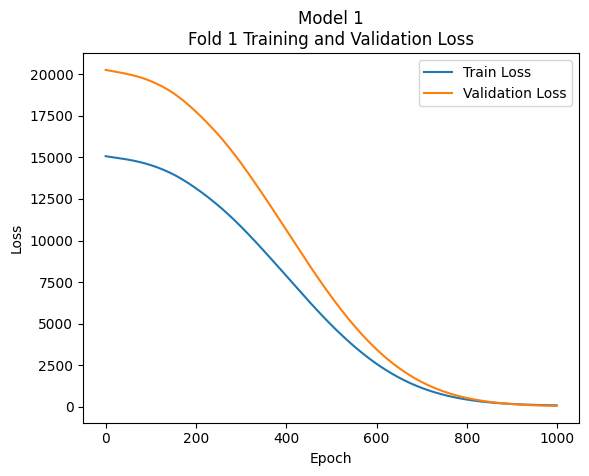

Fold [2/5], Final Val Loss (MSE): 185.0142, Final Val RMSE: 13.6020


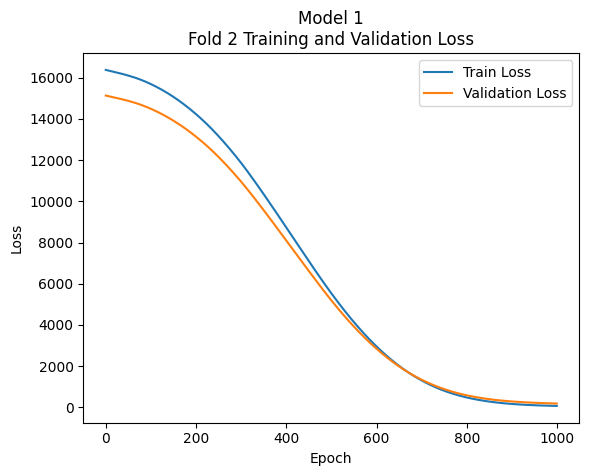

Fold [3/5], Final Val Loss (MSE): 76.6394, Final Val RMSE: 8.7544


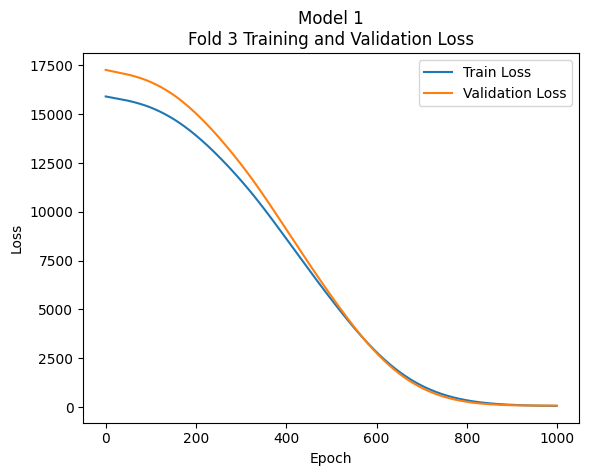

Fold [4/5], Final Val Loss (MSE): 44.3423, Final Val RMSE: 6.6590


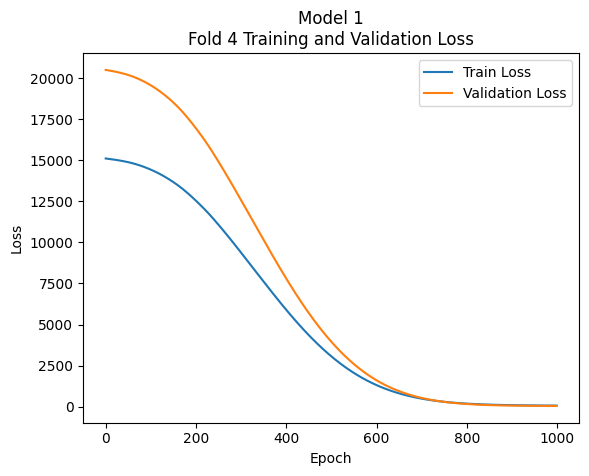

Fold [5/5], Final Val Loss (MSE): 54.0430, Final Val RMSE: 7.3514


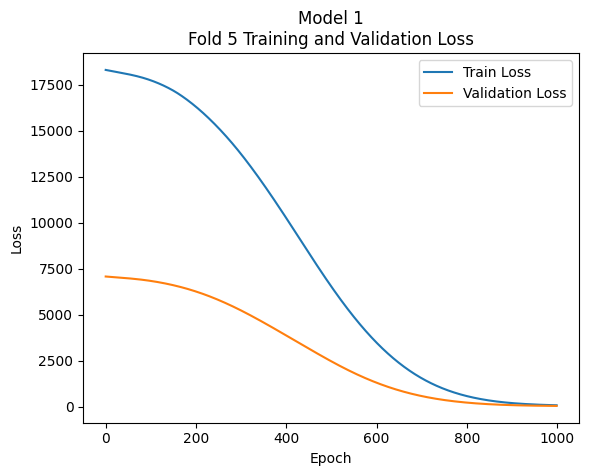


Mean CV Val Loss (MSE): 83.0775
Mean CV Val Loss (RMSE): 9.1147
Std CV Val Loss (MSE): 52.0477
Std CV Val Loss (RMSE): 7.2144


In [ ]:

# load data 

import torch


df = (pd.read_csv('../Data/modeling_data.csv')
      )

target_col = 'total_fresh_weight_g'

X = df.drop(columns=[target_col]).to_numpy(dtype=np.float32)
y = df[target_col].to_numpy(dtype=np.float32)

feature_names = df.drop(columns=[target_col]).columns.tolist()

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


#### Neural Network Model
class BasicNN(nn.Module): # inherits from Module
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__() # call initialization from module
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x
    
# pick manual seed
torch.manual_seed(42)

# hyperparameters    
input_size = X_train.shape[1]
hidden_size = 32
output_size = 1
learning_rate = .001
num_epochs = 1000

# loss function
criterion = nn.MSELoss()

# cross validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_val_losses = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    
    X_train_fold = X_train[train_idx]
    y_train_fold = y_train[train_idx]
    X_val_fold = X_train[val_idx]
    y_val_fold = y_train[val_idx]
    
    # standardize within each fold
    scaler = StandardScaler()
    X_train_fold = scaler.fit_transform(X_train_fold).astype(np.float32)
    X_val_fold = scaler.transform(X_val_fold).astype(np.float32)
    
    # convert to tensors
    X_train_tensor = torch.tensor(X_train_fold, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_fold, dtype=torch.float32).view(-1, 1)
    X_val_tensor = torch.tensor(X_val_fold, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val_fold, dtype=torch.float32).view(-1, 1)
    
    # initialize model
    model = BasicNN(input_size=input_size, hidden_size=hidden_size, output_size=output_size)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # train
    train_losses = []
    val_losses = []
    
    for epoch in range(num_epochs):
        model.train()
        outputs = model(X_train_tensor) # get predicted results
        loss = criterion(outputs, y_train_tensor) 
        optimizer.zero_grad() 
        loss.backward() # compute gradients
        optimizer.step() # update weights
        
        train_losses.append(loss.item())
        
        # validation
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_tensor)
            val_loss = criterion(val_outputs, y_val_tensor)
        
        val_losses.append(val_loss.item())
    
    cv_val_losses.append(val_losses[-1])
    
    print(f"Fold [{fold+1}/5], Final Val Loss (MSE): {val_losses[-1]:.4f}, Final Val RMSE: {np.sqrt(val_losses[-1]):.4f}")
    
    plt.figure()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Model 1\nFold {fold+1} Training and Validation Loss")
    plt.legend()
    plt.savefig(f'../Figures/fold_{fold+1}_training_validation_loss.png')
    plt.show()

print(f"\nMean CV Val Loss (MSE): {np.mean(cv_val_losses):.4f}")
print(f"Mean CV Val Loss (RMSE): {np.sqrt(np.mean(cv_val_losses)):.4f}")
print(f"Std CV Val Loss (MSE): {np.std(cv_val_losses):.4f}")
print(f"Std CV Val Loss (RMSE): {np.sqrt(np.std(cv_val_losses)):.4f}")



Epoch [1/1000], Train Loss: 16153.4268
Epoch [2/1000], Train Loss: 16149.4111
Epoch [3/1000], Train Loss: 16145.4170
Epoch [4/1000], Train Loss: 16141.4424
Epoch [5/1000], Train Loss: 16137.4717
Epoch [6/1000], Train Loss: 16133.4951
Epoch [7/1000], Train Loss: 16129.5029
Epoch [8/1000], Train Loss: 16125.5117
Epoch [9/1000], Train Loss: 16121.5156
Epoch [10/1000], Train Loss: 16117.5244
Epoch [11/1000], Train Loss: 16113.5312
Epoch [12/1000], Train Loss: 16109.5391
Epoch [13/1000], Train Loss: 16105.5596
Epoch [14/1000], Train Loss: 16101.5732
Epoch [15/1000], Train Loss: 16097.5820
Epoch [16/1000], Train Loss: 16093.5791
Epoch [17/1000], Train Loss: 16089.5664
Epoch [18/1000], Train Loss: 16085.5352
Epoch [19/1000], Train Loss: 16081.4873
Epoch [20/1000], Train Loss: 16077.4307
Epoch [21/1000], Train Loss: 16073.3564
Epoch [22/1000], Train Loss: 16069.2725
Epoch [23/1000], Train Loss: 16065.1689
Epoch [24/1000], Train Loss: 16061.0557
Epoch [25/1000], Train Loss: 16056.9365
Epoch [26

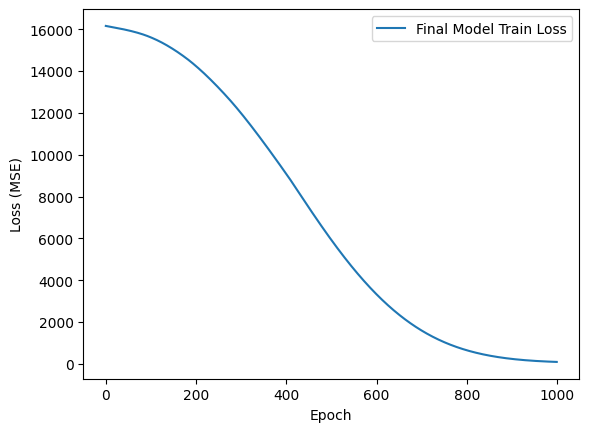

In [28]:
# train final model on full training set

# hyperparameters    
input_size = X_train.shape[1]
hidden_size = 32
output_size = 1
learning_rate = .001
num_epochs = 1000

# standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

# convert to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# initialize model
torch.manual_seed(42)
model1 = BasicNN(input_size=input_size, hidden_size=hidden_size, output_size=output_size)
optimizer = optim.Adam(model1.parameters(), lr=learning_rate)

# train final model and store training loss
train_losses = []

for epoch in range(num_epochs):
    model1.train()
    outputs = model1(X_train_tensor) # get predicted results
    loss = criterion(outputs, y_train_tensor) 
    optimizer.zero_grad() 
    loss.backward() # compute gradients
    optimizer.step() # update weights

    train_losses.append(loss.item())

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {loss.item():.4f}")

# final test evaluation
model1.eval()
with torch.no_grad():
    test_outputs = model1(X_test_tensor)
    test_loss = criterion(test_outputs, y_test_tensor)

print(f"\nFinal Test Loss (MSE): {test_loss.item():.4f}")
print(f"Final Test Loss (RMSE): {np.sqrt(test_loss.item()):.4f}")

plt.plot(train_losses, label="Final Model Train Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.savefig('../Figures/final_training_loss.png')
plt.show()

## Permutation Feature Importance (model1)
* Compute RMSE increase when each feature is randomly shuffled in the test set
* Repeated 20 times and computed average RMSE increase for each feature

Baseline RMSE: 10.351102

Permutation results (20-repeat average):
electrical_conductivity    RMSE=27.4403  (Δ=+17.0892,  sd=2.6749)
volume_flow_rate           RMSE=27.4002  (Δ=+17.0491,  sd=3.5086)
weight_lag_1               RMSE=27.2577  (Δ=+16.9066,  sd=3.1153)
temp_nutr                  RMSE=26.3365  (Δ=+15.9854,  sd=4.1457)
weight_lag_2               RMSE=24.2349  (Δ=+13.8838,  sd=2.4228)
volume                     RMSE=23.8278  (Δ=+13.4767,  sd=3.5889)
humidity                   RMSE=23.5083  (Δ=+13.1572,  sd=3.1101)
pressure                   RMSE=20.5875  (Δ=+10.2364,  sd=3.1687)
temp_env                   RMSE=18.7953  (Δ=+8.4442,  sd=2.7443)
carbon_dioxide             RMSE=16.9412  (Δ=+6.5901,  sd=2.4942)


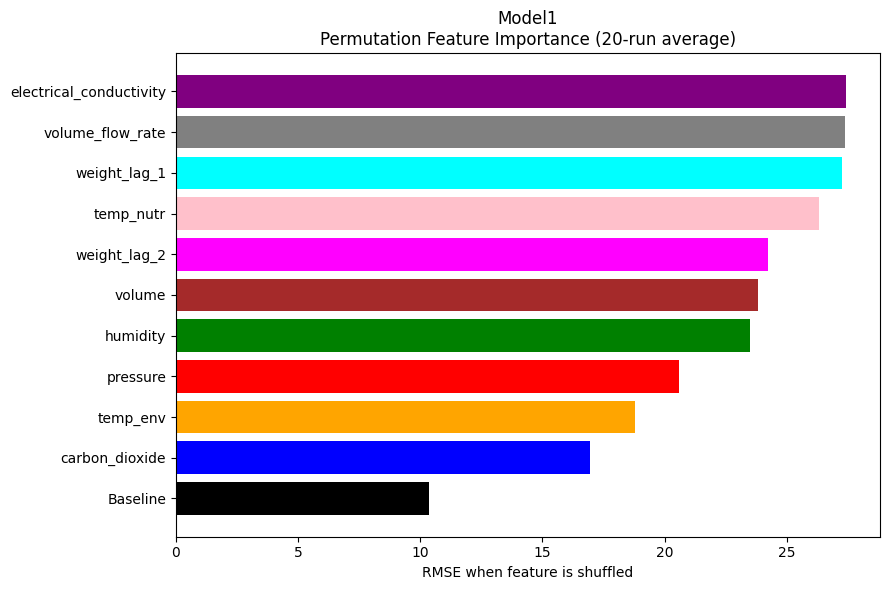

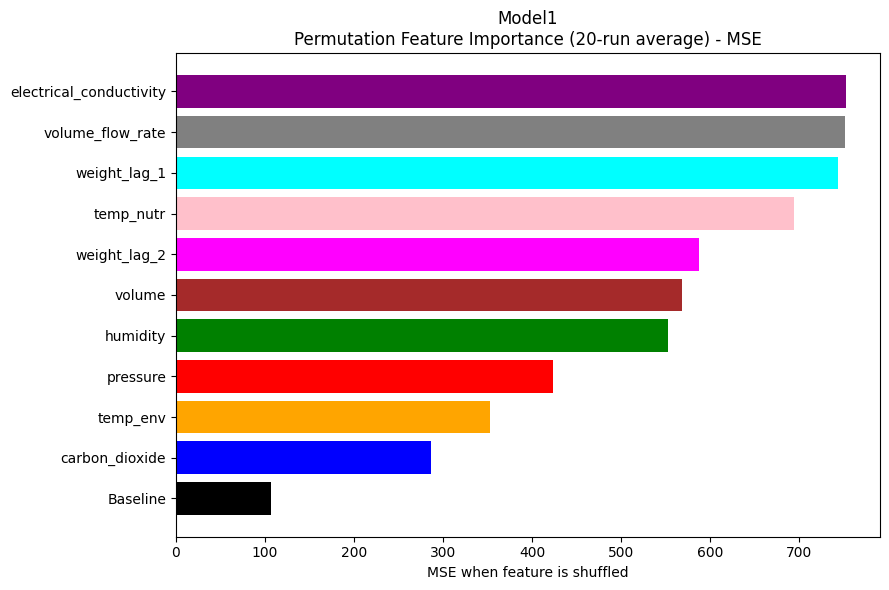

In [34]:
import numpy as np
import torch
import random
import matplotlib.pyplot as plt

# ==============================
# RMSE function
# ==============================
def rmse(y_pred, y_true):
    return np.sqrt(np.mean((y_pred - y_true) ** 2))

model1.eval()

# ==============================
# Baseline RMSE
# ==============================
with torch.no_grad():
    base_preds = model1(X_test_tensor).cpu().numpy()

y_true = y_test_tensor.cpu().numpy()
base_rmse = rmse(base_preds, y_true)

# ==============================
# Permutation Importance (20 repeats)
# ==============================
repeats = 20
perm_results = []
torch.manual_seed(42)

X_test_base = X_test_tensor.clone()
N = X_test_base.shape[0]

for j, name in enumerate(feature_names):
    rmses = []

    for r in range(repeats):
        X_perm = X_test_base.clone()

        # shuffle feature j
        idx = torch.randperm(N)
        X_perm[:, j] = X_perm[idx, j]

        with torch.no_grad():
            preds = model1(X_perm).cpu().numpy()

        rmses.append(rmse(preds, y_true))

    avg_perm_rmse = np.mean(rmses)
    std_perm_rmse = np.std(rmses)

    perm_results.append((name, avg_perm_rmse, std_perm_rmse))

# Sort by average permuted RMSE (largest first)
perm_results.sort(key=lambda x: x[1], reverse=True)

# ==============================
# Print results
# ==============================
print("Baseline RMSE:", round(base_rmse, 6))
print("\nPermutation results (20-repeat average):")

for name, avg_rmse, std_rmse in perm_results:
    delta = avg_rmse - base_rmse
    print(f"{name:25s}  RMSE={avg_rmse:.4f}  (Δ={delta:+.4f},  sd={std_rmse:.4f})")

# ==============================
# Plot
# ==============================

coef_colors = {
    'carbon_dioxide': 'blue',
    'temp_env': 'orange',
    'humidity': 'green',
    'pressure': 'red',
    'electrical_conductivity': 'purple',
    'volume': 'brown',
    'temp_nutr': 'pink',
    'volume_flow_rate': 'gray',
    'weight_lag_1': 'cyan',
    'weight_lag_2': 'magenta'
}

baseline_color = "black"

names = [n for n, _, _ in perm_results]
rmses = [r for _, r, _ in perm_results]
colors = [coef_colors.get(name, 'black') for name in names]

# Add baseline as separate bar
names_plot = names + ["Baseline"]
rmses_plot = rmses + [base_rmse]
colors_plot = colors + [baseline_color]

plt.figure(figsize=(9, 6))
plt.barh(names_plot[::-1], rmses_plot[::-1], color=colors_plot[::-1])

plt.xlabel("RMSE when feature is shuffled")
plt.title("Model1\nPermutation Feature Importance (20-run average)")
plt.tight_layout()

plt.savefig('../Figures/nnmodel1_permutation_importance_rmse.png', bbox_inches='tight')
plt.show()

# plot for mse instead of rmse
plt.figure(figsize=(9, 6))
plt.barh(names_plot[::-1], [r**2 for r in rmses_plot][::-1], color=colors_plot[::-1])
plt.xlabel("MSE when feature is shuffled")
plt.title("Model1\nPermutation Feature Importance (20-run average) - MSE")
plt.tight_layout()
plt.savefig('../Figures/nnmodel1_permutation_importance_mse.png', bbox_inches='tight')
plt.show()

## Perturbation Analysis (model1)

In [32]:
# baseline predictions

# fucntion that returns list of predictions after feature perturbation
def get_perturbed_predictions(model, X_test_tensor, feature_name, perturbation=0.1):
    with torch.no_grad():
        baseline_preds = model(X_test_tensor)

        X_perturbed = X_test_tensor.clone()
        X_perturbed[:, feature_names.index(feature_name)] *= (1 + perturbation)

        perturbed_preds = model(X_perturbed)

    return baseline_preds, perturbed_preds


get_perturbed_predictions(model1, X_test_tensor, 'electrical_conductivity', perturbation=0.1)


perturbation_results = []

for feature in feature_names:

    baseline_preds, perturbed_plus_10 = get_perturbed_predictions(
        model1, X_test_tensor, feature, perturbation=0.1
    )

    _, perturbed_minus_10 = get_perturbed_predictions(
        model1, X_test_tensor, feature, perturbation=-0.1
    )

    _, perturbed_plus_20 = get_perturbed_predictions(
        model1, X_test_tensor, feature, perturbation=0.2
    )

    _, perturbed_minus_20 = get_perturbed_predictions(
        model1, X_test_tensor, feature, perturbation=-0.2
    )

    _, perturbed_plus_50 = get_perturbed_predictions(
        model1, X_test_tensor, feature, perturbation=0.5
    )

    _, perturbed_minus_50 = get_perturbed_predictions(
        model1, X_test_tensor, feature, perturbation=-0.5
    )

    _, perturbed_plus_80 = get_perturbed_predictions(
        model1, X_test_tensor, feature, perturbation=0.8
    )

    _, perturbed_minus_80 = get_perturbed_predictions(
        model1, X_test_tensor, feature, perturbation=-0.8
    )

    plus_10_effect = (perturbed_plus_10 - baseline_preds).mean().item()
    minus_10_effect = (perturbed_minus_10 - baseline_preds).mean().item()
    plus_20_effect = (perturbed_plus_20 - baseline_preds).mean().item()
    minus_20_effect = (perturbed_minus_20 - baseline_preds).mean().item()
    plus_50_effect = (perturbed_plus_50 - baseline_preds).mean().item()
    minus_50_effect = (perturbed_minus_50 - baseline_preds).mean().item()
    plus_80_effect = (perturbed_plus_80 - baseline_preds).mean().item()
    minus_80_effect = (perturbed_minus_80 - baseline_preds).mean().item()

    perturbation_results.append({
        "feature": feature,
        "+10% effect (g)": plus_10_effect,
        "-10% effect (g)": minus_10_effect,
        "+20% effect (g)": plus_20_effect,
        "-20% effect (g)": minus_20_effect,
        "+50% effect (g)": plus_50_effect,
        "-50% effect (g)": minus_50_effect,
        "+80% effect (g)": plus_80_effect,
        "-80% effect (g)": minus_80_effect
    })

perturbation_df = pd.DataFrame(perturbation_results)

perturbation_df = perturbation_df.sort_values(
    by="+10% effect (g)",
    key=lambda x: x.abs(),
    ascending=False
).reset_index(drop=True)

perturbation_df = perturbation_df.round(4)

perturbation_df

,feature,+10% effect (g),-10% effect (g),+20% effect (g),-20% effect (g),+50% effect (g),-50% effect (g),+80% effect (g),-80% effect (g)
0,electrical_conductivity,1.6130,-1.6090,3.2596,-3.2180,8.2459,-8.0454,13.2819,-12.8506
1,weight_lag_1,1.5398,-1.5368,3.0914,-3.0737,7.7882,-7.6851,12.5271,-12.2957
2,volume,1.4389,-1.4389,2.8818,-2.8779,7.2263,-7.1948,11.5719,-11.5017
3,temp_nutr,1.3222,-1.3207,2.6529,-2.6417,6.6591,-6.6048,10.6643,-10.5573
4,weight_lag_2,1.2799,-1.2800,2.5639,-2.5600,6.4585,-6.4013,10.3725,-10.2468
5,pressure,1.1519,-1.1520,2.3038,-2.3044,5.7586,-5.7443,9.2136,-9.1644
6,humidity,1.1003,-1.1003,2.2005,-2.2007,5.5008,-5.5004,8.8007,-8.7971
7,volume_flow_rate,0.9838,-0.9841,1.9676,-1.9684,4.9221,-4.9214,7.8815,-7.8744
8,temp_env,0.4902,-0.4648,0.9805,-0.9107,2.5955,-2.0982,4.6627,-3.2504
9,carbon_dioxide,0.4727,-0.4728,0.9449,-0.9429,2.3610,-2.2684,3.7770,-3.4676


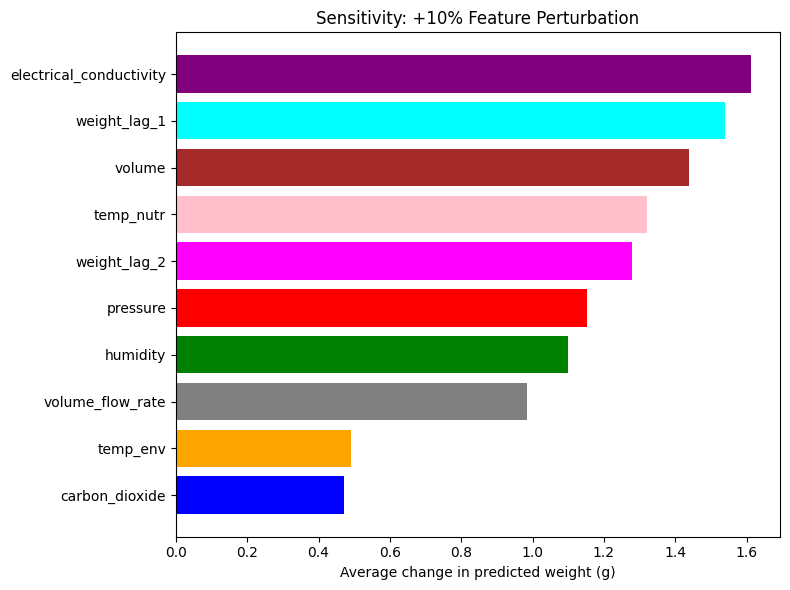

In [ ]:
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt

# map feature colors
colors = perturbation_df["feature"].map(coef_colors)

plt.figure(figsize=(8,6))

plt.barh(
    perturbation_df["feature"],
    perturbation_df["+10% effect (g)"],
    color=colors
)

plt.xlabel("Average change in predicted weight (g)")
plt.title("Model1\nSensitivity: +10% Feature Perturbation")

plt.gca().invert_yaxis()  # most important feature at top

plt.tight_layout()
plt.show()

# Neural Network 2 - (model2)

**Key Change**: Trained model without lag features (weight_lag_1 and weight_lag_2)since they are not be modifiable in real-time. 

**NOTE**: This model dataframe still does not use all the time periods in data (due lag features added for model1) 

* Preprocessing: Standardized features 
* Model: Basic feedforward NN with 1 hidden layer (32 neurons, ReLU activation)
* Adam optimizer, MSE loss
* Hyperparameters:
  * Adam optimizer
  * MSE Loss 
  * Hidden layer size: 32
  * Learning rate: 0.01
  * Epochs: 100
  * Used 5-fold cross-validation to select hyperparameters
* Evaluation: Final test loss (MSE and RMSE)

Features: 
  * carbon_dioxide
  * temp_env
  * humidity
  * pressure
  * electrical_conductivity
  * volume
  * temp_nutr
  * volume_flow_rate

Target: total_fresh_weight_g

Fold [1/5], Final Val Loss (MSE): 187.5731, Final Val RMSE: 13.6957


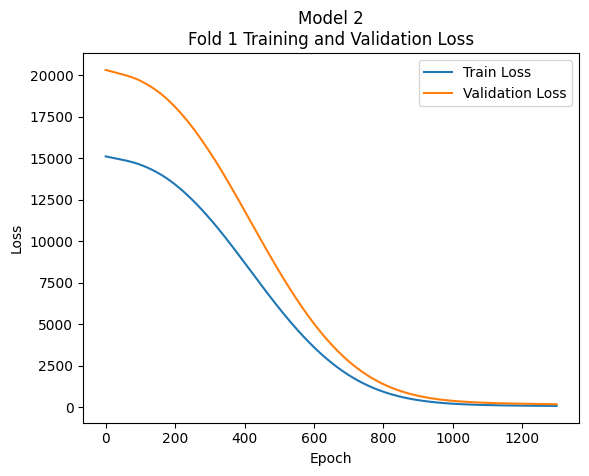

Fold [2/5], Final Val Loss (MSE): 190.8223, Final Val RMSE: 13.8138


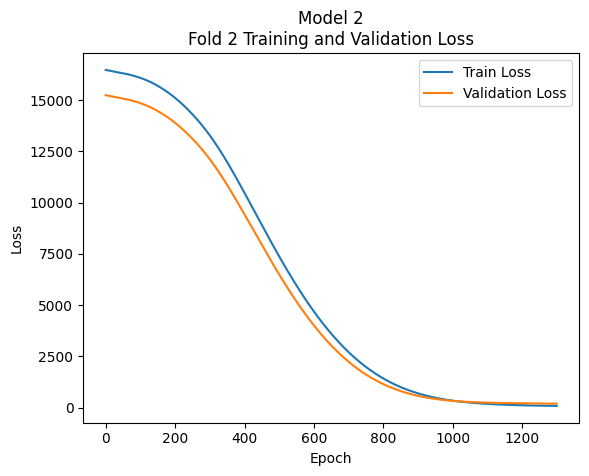

Fold [3/5], Final Val Loss (MSE): 59.4080, Final Val RMSE: 7.7077


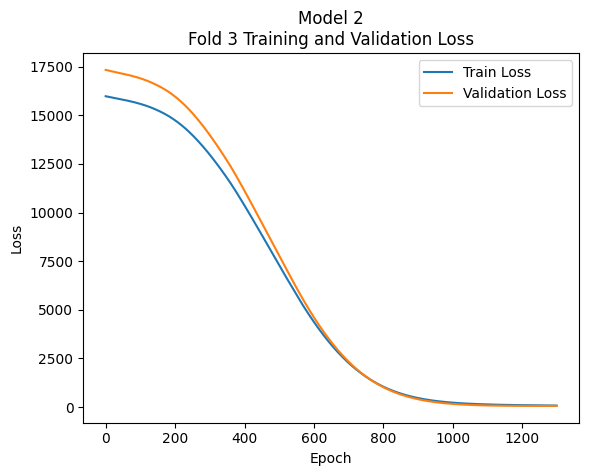

Fold [4/5], Final Val Loss (MSE): 60.6176, Final Val RMSE: 7.7857


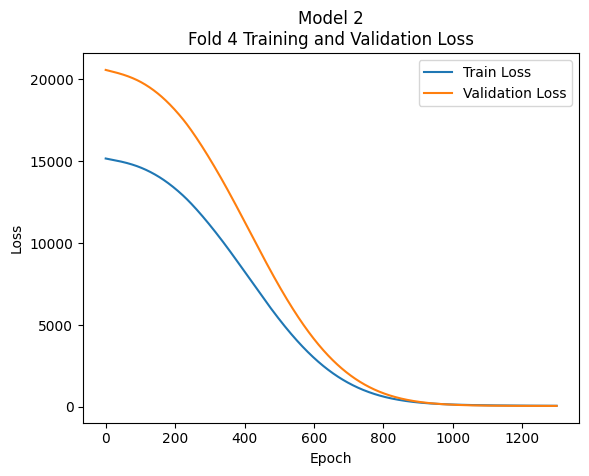

Fold [5/5], Final Val Loss (MSE): 51.0547, Final Val RMSE: 7.1453


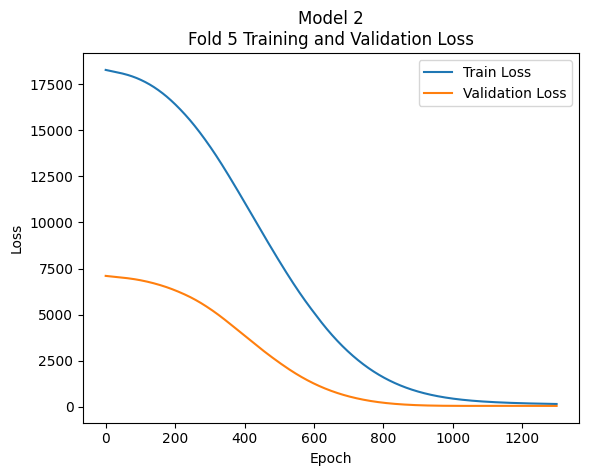


Model 2 Mean CV Val Loss (MSE): 109.8952
Model 2 Mean CV Val Loss (RMSE): 10.4831
Model 2 Std CV Val Loss (MSE): 64.8421
Model 2 Std CV Val Loss (RMSE): 8.0525


In [21]:
# Model 2

# load data 

import torch


df = (pd.read_csv('../Data/modeling_data.csv')
      )
columns_to_drop = ['weight_lag_1', 'weight_lag_2']
df = df.drop(columns=columns_to_drop)

target_col = 'total_fresh_weight_g'

X = df.drop(columns=[target_col]).to_numpy(dtype=np.float32)
y = df[target_col].to_numpy(dtype=np.float32)

feature_names = df.drop(columns=[target_col]).columns.tolist()

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


#### Neural Network Model
class BasicNN(nn.Module): # inherits from Module
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__() # call initialization from module
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x
    
# pick manual seed
torch.manual_seed(42)

# hyperparameters    
input_size = X_train.shape[1]
hidden_size = 32
output_size = 1
learning_rate = .001
num_epochs = 1300

# loss function
criterion = nn.MSELoss()

# cross validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_val_losses = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    
    X_train_fold = X_train[train_idx]
    y_train_fold = y_train[train_idx]
    X_val_fold = X_train[val_idx]
    y_val_fold = y_train[val_idx]
    
    # standardize within each fold
    scaler = StandardScaler()
    X_train_fold = scaler.fit_transform(X_train_fold).astype(np.float32)
    X_val_fold = scaler.transform(X_val_fold).astype(np.float32)
    
    # convert to tensors
    X_train_tensor = torch.tensor(X_train_fold, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_fold, dtype=torch.float32).view(-1, 1)
    X_val_tensor = torch.tensor(X_val_fold, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val_fold, dtype=torch.float32).view(-1, 1)
    
    # initialize model
    model = BasicNN(input_size=input_size, hidden_size=hidden_size, output_size=output_size)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # train
    train_losses = []
    val_losses = []
    
    for epoch in range(num_epochs):
        model.train()
        outputs = model(X_train_tensor) # get predicted results
        loss = criterion(outputs, y_train_tensor) 
        optimizer.zero_grad() 
        loss.backward() # compute gradients
        optimizer.step() # update weights
        
        train_losses.append(loss.item())
        
        # validation
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_tensor)
            val_loss = criterion(val_outputs, y_val_tensor)
        
        val_losses.append(val_loss.item())
    
    cv_val_losses.append(val_losses[-1])
    
    print(f"Fold [{fold+1}/5], Final Val Loss (MSE): {val_losses[-1]:.4f}, Final Val RMSE: {np.sqrt(val_losses[-1]):.4f}")
    
    plt.figure()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Model 2\nFold {fold+1} Training and Validation Loss")
    plt.legend()
    plt.savefig(f'../Figures/fold_{fold+1}_training_validation_loss.png')
    plt.show()

print(f"\nModel 2 Mean CV Val Loss (MSE): {np.mean(cv_val_losses):.4f}")
print(f"Model 2 Mean CV Val Loss (RMSE): {np.sqrt(np.mean(cv_val_losses)):.4f}")
print(f"Model 2 Std CV Val Loss (MSE): {np.std(cv_val_losses):.4f}")
print(f"Model 2 Std CV Val Loss (RMSE): {np.sqrt(np.std(cv_val_losses)):.4f}")



Epoch [1/1300], Train Loss: 16153.4268
Epoch [2/1300], Train Loss: 16149.4111
Epoch [3/1300], Train Loss: 16145.4170
Epoch [4/1300], Train Loss: 16141.4424
Epoch [5/1300], Train Loss: 16137.4717
Epoch [6/1300], Train Loss: 16133.4951
Epoch [7/1300], Train Loss: 16129.5029
Epoch [8/1300], Train Loss: 16125.5117
Epoch [9/1300], Train Loss: 16121.5156
Epoch [10/1300], Train Loss: 16117.5244
Epoch [11/1300], Train Loss: 16113.5312
Epoch [12/1300], Train Loss: 16109.5391
Epoch [13/1300], Train Loss: 16105.5596
Epoch [14/1300], Train Loss: 16101.5732
Epoch [15/1300], Train Loss: 16097.5820
Epoch [16/1300], Train Loss: 16093.5791
Epoch [17/1300], Train Loss: 16089.5664
Epoch [18/1300], Train Loss: 16085.5352
Epoch [19/1300], Train Loss: 16081.4873
Epoch [20/1300], Train Loss: 16077.4307
Epoch [21/1300], Train Loss: 16073.3564
Epoch [22/1300], Train Loss: 16069.2725
Epoch [23/1300], Train Loss: 16065.1689
Epoch [24/1300], Train Loss: 16061.0557
Epoch [25/1300], Train Loss: 16056.9365
Epoch [26

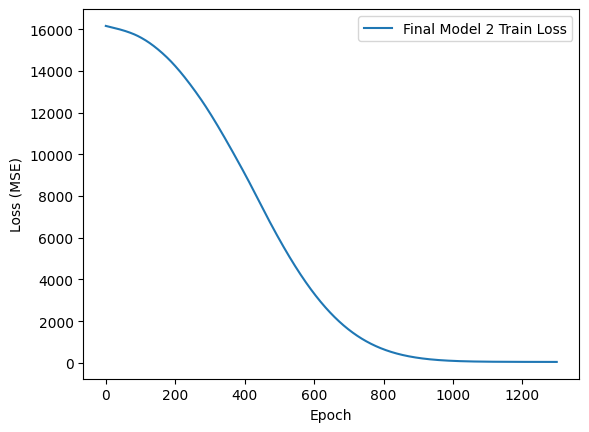

In [35]:
# train final model on full training set

# hyperparameters    
input_size = X_train.shape[1]
hidden_size = 32
output_size = 1
learning_rate = .001
num_epochs = 1300

# standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

# convert to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# initialize model
torch.manual_seed(42)
model2 = BasicNN(input_size=input_size, hidden_size=hidden_size, output_size=output_size)
optimizer = optim.Adam(model2.parameters(), lr=learning_rate)

# train final model and store training loss
train_losses = []

for epoch in range(num_epochs):
    model2.train()
    outputs = model2(X_train_tensor) # get predicted results
    loss = criterion(outputs, y_train_tensor) 
    optimizer.zero_grad() 
    loss.backward() # compute gradients
    optimizer.step() # update weights

    train_losses.append(loss.item())

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {loss.item():.4f}")

# final test evaluation
model2.eval()
with torch.no_grad():
    test_outputs = model2(X_test_tensor)
    test_loss = criterion(test_outputs, y_test_tensor)

print(f"\nFinal Test Loss (MSE): {test_loss.item():.4f}")
print(f"Final Test Loss (RMSE): {np.sqrt(test_loss.item()):.4f}")

plt.plot(train_losses, label="Final Model 2 Train Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.savefig('../Figures/final_model_2_training_loss.png')
plt.show()

# Neural Network 3 - (model3)

**Key Changes**: 
* Trained model without lag features (weight_lag_1 and weight_lag_2)since they are not be modifiable in real-time. 
* Also used full time period (so more data points) since lag features are not being used.


Hyperparameters:
* Preprocessing: Standardized features 
* Model: Basic feedforward NN with 1 hidden layer (32 neurons, ReLU activation)
* Adam optimizer, MSE loss
* Hyperparameters:
  * Adam optimizer
  * MSE Loss 
  * Hidden layer size: 32
  * Learning rate: 0.01
  * Epochs: 100
  * Used 5-fold cross-validation to select hyperparameters
* Evaluation: Final test loss (MSE and RMSE)

Features: 
  * carbon_dioxide
  * temp_env
  * humidity
  * pressure
  * electrical_conductivity
  * volume
  * temp_nutr
  * volume_flow_rate

Target: total_fresh_weight_g

Fold [1/5], Final Val Loss (MSE): 123.7575, Final Val RMSE: 11.1246


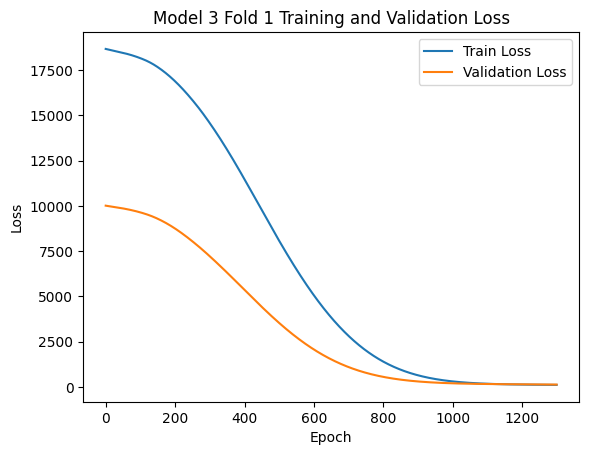

Fold [2/5], Final Val Loss (MSE): 110.8513, Final Val RMSE: 10.5286


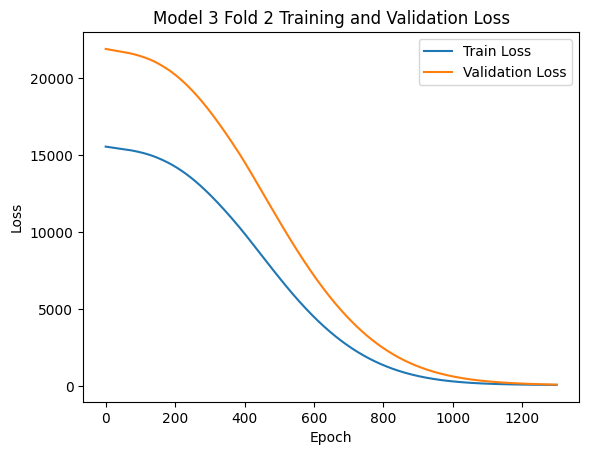

Fold [3/5], Final Val Loss (MSE): 103.1151, Final Val RMSE: 10.1546


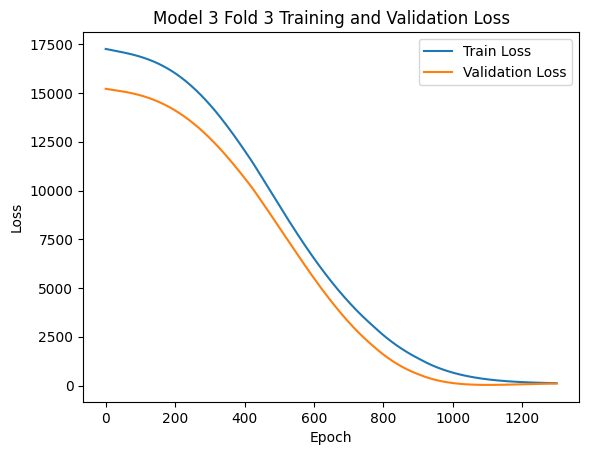

Fold [4/5], Final Val Loss (MSE): 151.6703, Final Val RMSE: 12.3154


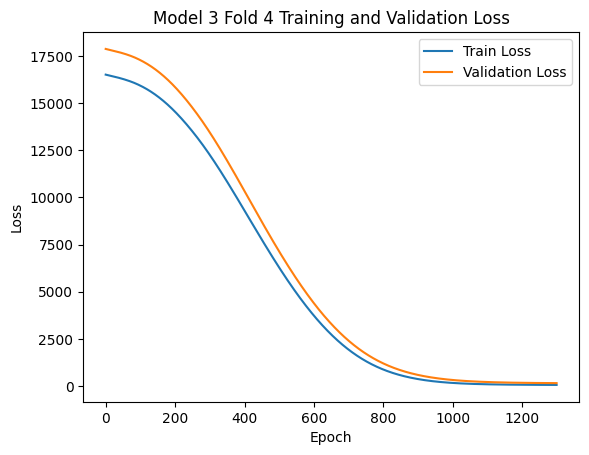

Fold [5/5], Final Val Loss (MSE): 72.8023, Final Val RMSE: 8.5324


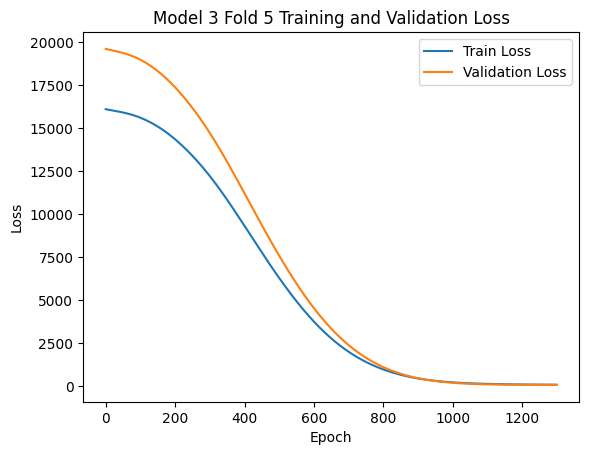


Model 3 Mean CV Val Loss (MSE): 112.4393
Model 3 Mean CV Val Loss (RMSE): 10.6037
Model 3 Std CV Val Loss (MSE): 25.7982
Model 3 Std CV Val Loss (RMSE): 5.0792


In [53]:
# Model 3

# load data

FILE_PATH = '../Data/CleanData/Trial_1_Mean_Sensor_FW_No_Lag.csv'
df = pd.read_csv(FILE_PATH)

df = df[df['day'] > 0].reset_index(drop=True)
columns_to_drop = ['day', 'plant-id', 'baseline_g'] 
df = df.drop(columns=columns_to_drop)

import torch

target_col = 'total_fresh_weight_g'

X = df.drop(columns=[target_col]).to_numpy(dtype=np.float32)
y = df[target_col].to_numpy(dtype=np.float32)

feature_names = df.drop(columns=[target_col]).columns.tolist()

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


#### Neural Network Model
class BasicNN(nn.Module): # inherits from Module
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__() # call initialization from module
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x
    
# pick manual seed
torch.manual_seed(42)

# hyperparameters    
input_size = X_train.shape[1]
hidden_size = 32
output_size = 1
learning_rate = .001
num_epochs = 1300

# loss function
criterion = nn.MSELoss()

# cross validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_val_losses = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    
    X_train_fold = X_train[train_idx]
    y_train_fold = y_train[train_idx]
    X_val_fold = X_train[val_idx]
    y_val_fold = y_train[val_idx]
    
    # standardize within each fold
    scaler = StandardScaler()
    X_train_fold = scaler.fit_transform(X_train_fold).astype(np.float32)
    X_val_fold = scaler.transform(X_val_fold).astype(np.float32)
    
    # convert to tensors
    X_train_tensor = torch.tensor(X_train_fold, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_fold, dtype=torch.float32).view(-1, 1)
    X_val_tensor = torch.tensor(X_val_fold, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val_fold, dtype=torch.float32).view(-1, 1)
    
    # initialize model
    model = BasicNN(input_size=input_size, hidden_size=hidden_size, output_size=output_size)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # train
    train_losses = []
    val_losses = []
    
    for epoch in range(num_epochs):
        model.train()
        outputs = model(X_train_tensor) # get predicted results
        loss = criterion(outputs, y_train_tensor) 
        optimizer.zero_grad() 
        loss.backward() # compute gradients
        optimizer.step() # update weights
        
        train_losses.append(loss.item())
        
        # validation
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_tensor)
            val_loss = criterion(val_outputs, y_val_tensor)
        
        val_losses.append(val_loss.item())
    
    cv_val_losses.append(val_losses[-1])
    
    print(f"Fold [{fold+1}/5], Final Val Loss (MSE): {val_losses[-1]:.4f}, Final Val RMSE: {np.sqrt(val_losses[-1]):.4f}")
    
    plt.figure()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Model 3 Fold {fold+1} Training and Validation Loss")
    plt.legend()
    plt.savefig(f'../Figures/fold_{fold+1}_training_validation_loss.png')
    plt.show()

print(f"\nModel 3 Mean CV Val Loss (MSE): {np.mean(cv_val_losses):.4f}")
print(f"Model 3 Mean CV Val Loss (RMSE): {np.sqrt(np.mean(cv_val_losses)):.4f}")
print(f"Model 3 Std CV Val Loss (MSE): {np.std(cv_val_losses):.4f}")
print(f"Model 3 Std CV Val Loss (RMSE): {np.sqrt(np.std(cv_val_losses)):.4f}")



# Neural Network 4 - (model4)

**Key Changes**:
* Using a change in weight variable as target


In [37]:
FILE_PATH = '../Data/CleanData/Trial_1_Mean_Sensor_FW_No_Lag.csv'
df = pd.read_csv(FILE_PATH)

# df = df[df['day'] > 0].reset_index(drop=True)
# columns_to_drop = ['day', 'plant-id', 'baseline_g'] 
# df = df.drop(columns=columns_to_drop)
df

,day,plant-id,total_fresh_weight_g,baseline_g,carbon_dioxide,temp_env,humidity,pressure,electrical_conductivity,volume,temp_nutr,volume_flow_rate
0,0.0,6.0,29.1,25.22,461.250000,22.528333,62.394167,98838.439167,1300.625000,1010.277917,23.835208,1.160000
1,0.0,4.0,29.3,25.22,461.250000,22.528333,62.394167,98838.439167,1300.625000,1010.277917,23.835208,1.160000
2,0.0,9.0,29.6,25.22,461.250000,22.528333,62.394167,98838.439167,1300.625000,1010.277917,23.835208,1.160000
3,0.0,1.0,29.7,25.22,461.250000,22.528333,62.394167,98838.439167,1300.625000,1010.277917,23.835208,1.160000
4,0.0,8.0,29.8,25.22,461.250000,22.528333,62.394167,98838.439167,1300.625000,1010.277917,23.835208,1.160000
...,...,...,...,...,...,...,...,...,...,...,...,...
75,28.0,10.0,246.0,25.22,511.530612,22.304286,71.859592,99342.587347,1943.295918,550.176327,26.928286,0.213673
76,28.0,4.0,246.0,25.22,511.530612,22.304286,71.859592,99342.587347,1943.295918,550.176327,26.928286,0.213673
77,28.0,9.0,248.0,25.22,511.530612,22.304286,71.859592,99342.587347,1943.295918,550.176327,26.928286,0.213673
78,28.0,2.0,243.0,25.22,511.530612,22.304286,71.859592,99342.587347,1943.295918,550.176327,26.928286,0.213673


In [ ]:
# add change in weight variable 
# but group the change by plant id so that we don't have changes across different plants


,day,plant-id,total_fresh_weight_g,baseline_g,carbon_dioxide,temp_env,humidity,pressure,electrical_conductivity,volume,temp_nutr,volume_flow_rate,fw_change_g
0,0.0,6.0,29.1,25.22,461.250000,22.528333,62.394167,98838.439167,1300.625000,1010.277917,23.835208,1.160000,0.0
1,0.0,4.0,29.3,25.22,461.250000,22.528333,62.394167,98838.439167,1300.625000,1010.277917,23.835208,1.160000,0.0
2,0.0,9.0,29.6,25.22,461.250000,22.528333,62.394167,98838.439167,1300.625000,1010.277917,23.835208,1.160000,0.0
3,0.0,1.0,29.7,25.22,461.250000,22.528333,62.394167,98838.439167,1300.625000,1010.277917,23.835208,1.160000,0.0
4,0.0,8.0,29.8,25.22,461.250000,22.528333,62.394167,98838.439167,1300.625000,1010.277917,23.835208,1.160000,0.0
5,0.0,2.0,30.1,25.22,461.250000,22.528333,62.394167,98838.439167,1300.625000,1010.277917,23.835208,1.160000,0.0
6,0.0,5.0,30.2,25.22,461.250000,22.528333,62.394167,98838.439167,1300.625000,1010.277917,23.835208,1.160000,0.0
7,0.0,7.0,30.4,25.22,461.250000,22.528333,62.394167,98838.439167,1300.625000,1010.277917,23.835208,1.160000,0.0
8,0.0,10.0,31.1,25.22,461.250000,22.528333,62.394167,98838.439167,1300.625000,1010.277917,23.835208,1.160000,0.0
9,0.0,3.0,31.8,25.22,461.250000,22.528333,62.394167,98838.439167,1300.625000,1010.277917,23.835208,1.160000,0.0


In [ ]:
df.columns
# Index(['day', 'plant-id', 'total_fresh_weight_g', 'baseline_g',
#        'carbon_dioxide', 'temp_env', 'humidity', 'pressure',
#        'electrical_conductivity', 'volume', 'temp_nutr', 'volume_flow_rate'],
#       dtype='object')

Index(['day', 'plant-id', 'total_fresh_weight_g', 'baseline_g',
       'carbon_dioxide', 'temp_env', 'humidity', 'pressure',
       'electrical_conductivity', 'volume', 'temp_nutr', 'volume_flow_rate'],
      dtype='object')

Fold [1/5], Final Val Loss (MSE): 19.0971, Final Val RMSE: 4.3700


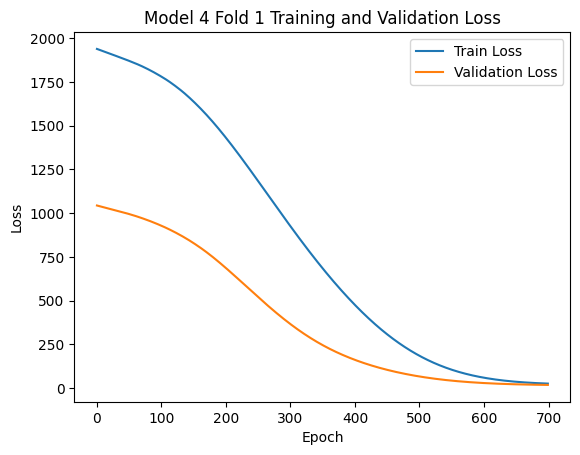

Fold [2/5], Final Val Loss (MSE): 36.3348, Final Val RMSE: 6.0278


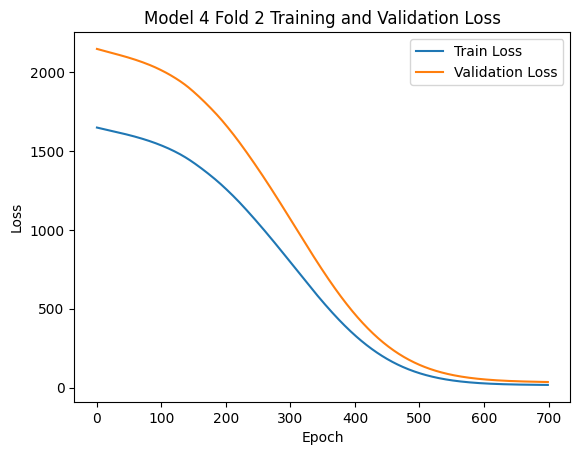

Fold [3/5], Final Val Loss (MSE): 34.9910, Final Val RMSE: 5.9153


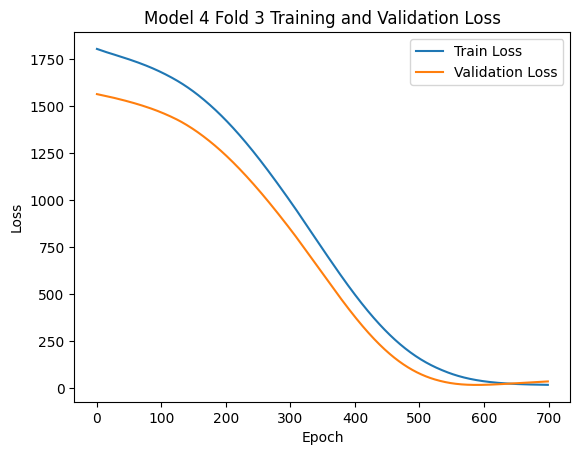

Fold [4/5], Final Val Loss (MSE): 15.2930, Final Val RMSE: 3.9106


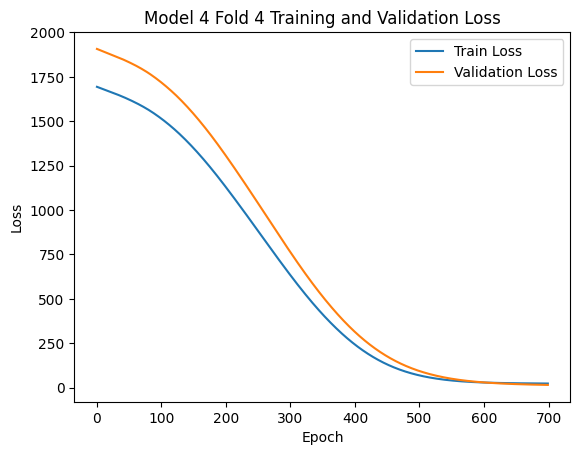

Fold [5/5], Final Val Loss (MSE): 17.2755, Final Val RMSE: 4.1564


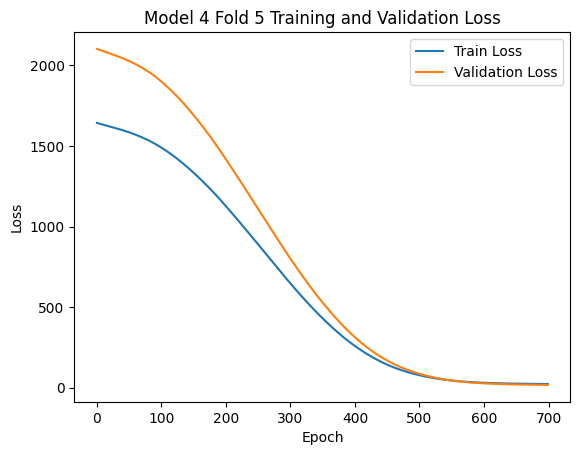


Model 4 Mean CV Val Loss (MSE): 24.5983
Model 4 Mean CV Val Loss (RMSE): 4.9597
Model 4 Std CV Val Loss (MSE): 9.1239
Model 4 Std CV Val Loss (RMSE): 3.0206


In [59]:
# Model 4

# load data and drop columns and day zero


FILE_PATH = '../Data/CleanData/Trial_1_Mean_Sensor_FW_No_Lag.csv'
df = pd.read_csv(FILE_PATH)

df['fw_change_g'] = df.groupby('plant-id')['total_fresh_weight_g'].diff().fillna(0) # add weight change variable
df = df[df['day'] > 0].reset_index(drop=True) # drop day zero
columns_to_drop = ['day', 'plant-id', 'baseline_g', 'total_fresh_weight_g'] # drop columns not needed for modeling
df = df.drop(columns=columns_to_drop)

import torch

target_col = 'fw_change_g'

X = df.drop(columns=[target_col]).to_numpy(dtype=np.float32)
y = df[target_col].to_numpy(dtype=np.float32)

feature_names = df.drop(columns=[target_col]).columns.tolist()

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


#### Neural Network Model
class BasicNN(nn.Module): # inherits from Module
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__() # call initialization from module
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x
    
# pick manual seed
torch.manual_seed(42)

# hyperparameters    
input_size = X_train.shape[1]
hidden_size = 32
output_size = 1
learning_rate = .001
num_epochs = 700

# loss function
criterion = nn.MSELoss()

# cross validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_val_losses = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    
    X_train_fold = X_train[train_idx]
    y_train_fold = y_train[train_idx]
    X_val_fold = X_train[val_idx]
    y_val_fold = y_train[val_idx]
    
    # standardize within each fold
    scaler = StandardScaler()
    X_train_fold = scaler.fit_transform(X_train_fold).astype(np.float32)
    X_val_fold = scaler.transform(X_val_fold).astype(np.float32)
    
    # convert to tensors
    X_train_tensor = torch.tensor(X_train_fold, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_fold, dtype=torch.float32).view(-1, 1)
    X_val_tensor = torch.tensor(X_val_fold, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val_fold, dtype=torch.float32).view(-1, 1)
    
    # initialize model
    model = BasicNN(input_size=input_size, hidden_size=hidden_size, output_size=output_size)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # train
    train_losses = []
    val_losses = []
    
    for epoch in range(num_epochs):
        model.train()
        outputs = model(X_train_tensor) # get predicted results
        loss = criterion(outputs, y_train_tensor) 
        optimizer.zero_grad() 
        loss.backward() # compute gradients
        optimizer.step() # update weights
        
        train_losses.append(loss.item())
        
        # validation
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_tensor)
            val_loss = criterion(val_outputs, y_val_tensor)
        
        val_losses.append(val_loss.item())
    
    cv_val_losses.append(val_losses[-1])
    
    print(f"Fold [{fold+1}/5], Final Val Loss (MSE): {val_losses[-1]:.4f}, Final Val RMSE: {np.sqrt(val_losses[-1]):.4f}")
    
    plt.figure()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Model 4 Fold {fold+1} Training and Validation Loss")
    plt.legend()
    plt.savefig(f'../Figures/fold_{fold+1}_training_validation_loss.png')
    plt.show()

print(f"\nModel 4 Mean CV Val Loss (MSE): {np.mean(cv_val_losses):.4f}")
print(f"Model 4 Mean CV Val Loss (RMSE): {np.sqrt(np.mean(cv_val_losses)):.4f}")
print(f"Model 4 Std CV Val Loss (MSE): {np.std(cv_val_losses):.4f}")
print(f"Model 4 Std CV Val Loss (RMSE): {np.sqrt(np.std(cv_val_losses)):.4f}")



Epoch [1/700], Train Loss: 1746.8691
Epoch [2/700], Train Loss: 1745.5150
Epoch [3/700], Train Loss: 1744.1635
Epoch [4/700], Train Loss: 1742.8148
Epoch [5/700], Train Loss: 1741.4690
Epoch [6/700], Train Loss: 1740.1256
Epoch [7/700], Train Loss: 1738.7853
Epoch [8/700], Train Loss: 1737.4480
Epoch [9/700], Train Loss: 1736.1130
Epoch [10/700], Train Loss: 1734.7799
Epoch [11/700], Train Loss: 1733.4459
Epoch [12/700], Train Loss: 1732.1123
Epoch [13/700], Train Loss: 1730.7795
Epoch [14/700], Train Loss: 1729.4476
Epoch [15/700], Train Loss: 1728.1168
Epoch [16/700], Train Loss: 1726.7861
Epoch [17/700], Train Loss: 1725.4537
Epoch [18/700], Train Loss: 1724.1218
Epoch [19/700], Train Loss: 1722.7927
Epoch [20/700], Train Loss: 1721.4657
Epoch [21/700], Train Loss: 1720.1373
Epoch [22/700], Train Loss: 1718.8077
Epoch [23/700], Train Loss: 1717.4769
Epoch [24/700], Train Loss: 1716.1449
Epoch [25/700], Train Loss: 1714.8118
Epoch [26/700], Train Loss: 1713.4919
Epoch [27/700], Train

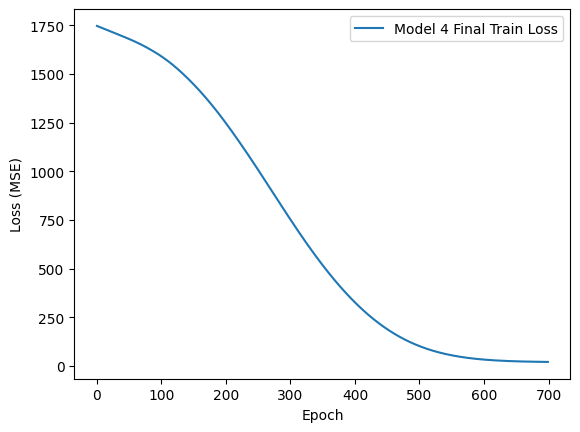

In [61]:
# MODEL 4 FINAL TRAINING

# hyperparameters    
input_size = X_train.shape[1]
hidden_size = 32
output_size = 1
learning_rate = .001
num_epochs = 700

# standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

# convert to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# initialize model
torch.manual_seed(42)
model4 = BasicNN(input_size=input_size, hidden_size=hidden_size, output_size=output_size)
optimizer = optim.Adam(model4.parameters(), lr=learning_rate)

# train final model and store training loss
train_losses = []

for epoch in range(num_epochs):
    model4.train()
    outputs = model4(X_train_tensor) # get predicted results
    loss = criterion(outputs, y_train_tensor) 
    optimizer.zero_grad() 
    loss.backward() # compute gradients
    optimizer.step() # update weights

    train_losses.append(loss.item())

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {loss.item():.4f}")

# final test evaluation
model4.eval()
with torch.no_grad():
    test_outputs = model4(X_test_tensor)
    test_loss = criterion(test_outputs, y_test_tensor)

print(f"\nModel 4 Final Test Loss (MSE): {test_loss.item():.4f}")
print(f"Model 4 Final Test Loss (RMSE): {np.sqrt(test_loss.item()):.4f}")

plt.plot(train_losses, label="Model 4 Final Train Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
# plt.savefig('../Figures/model4_final_training_loss.png')
plt.show()

In [60]:
df['fw_change_g'].min(), df['fw_change_g'].max(), df['fw_change_g'].mean()

(2.0, 83.0, 29.927142857142858)

## Permutation Importance (model4)

Baseline RMSE: 3.038468

Permutation results (20-repeat average):
carbon_dioxide             RMSE=8.9057  (Δ=+5.8672,  sd=1.3666)
humidity                   RMSE=7.6283  (Δ=+4.5899,  sd=1.3429)
volume                     RMSE=7.4284  (Δ=+4.3899,  sd=1.5625)
electrical_conductivity    RMSE=7.3017  (Δ=+4.2632,  sd=1.5797)
temp_nutr                  RMSE=6.3825  (Δ=+3.3440,  sd=1.2848)
pressure                   RMSE=6.3090  (Δ=+3.2705,  sd=1.4021)
volume_flow_rate           RMSE=6.0931  (Δ=+3.0546,  sd=1.0947)
temp_env                   RMSE=5.8801  (Δ=+2.8416,  sd=0.8655)


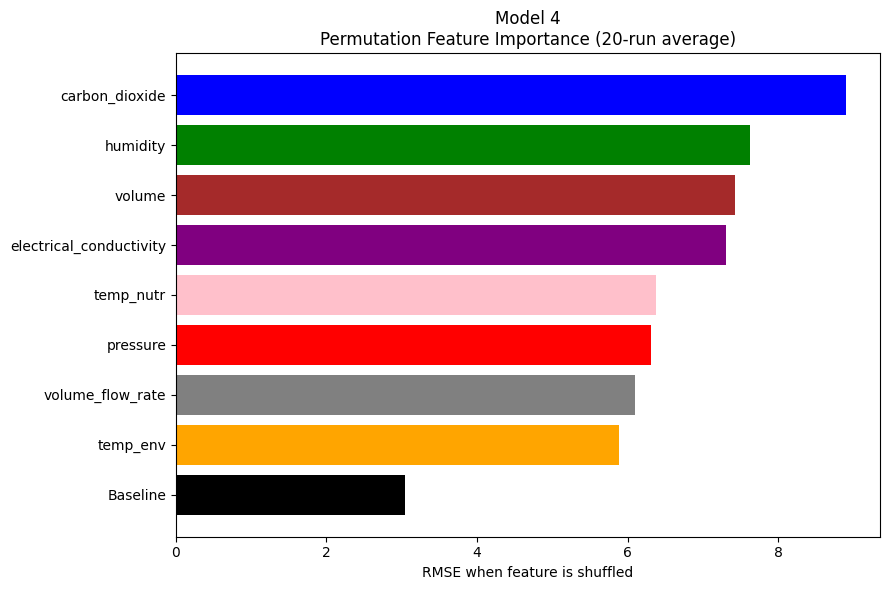

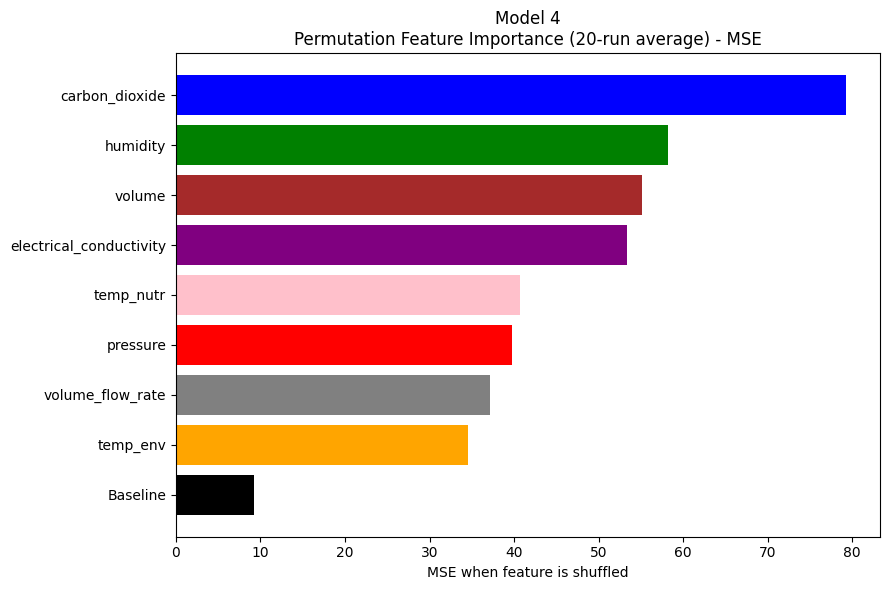

In [62]:
# MODEL 4 PERMUTATION IMPORTANCE
import numpy as np
import torch
import random
import matplotlib.pyplot as plt

# ==============================
# RMSE function
# ==============================
def rmse(y_pred, y_true):
    return np.sqrt(np.mean((y_pred - y_true) ** 2))

model4.eval()

# ==============================
# Baseline RMSE
# ==============================
with torch.no_grad():
    base_preds = model4(X_test_tensor).cpu().numpy()

y_true = y_test_tensor.cpu().numpy()
base_rmse = rmse(base_preds, y_true)

# ==============================
# Permutation Importance (20 repeats)
# ==============================
repeats = 20
perm_results = []
torch.manual_seed(42)

X_test_base = X_test_tensor.clone()
N = X_test_base.shape[0]

for j, name in enumerate(feature_names):
    rmses = []

    for r in range(repeats):
        X_perm = X_test_base.clone()

        # shuffle feature j
        idx = torch.randperm(N)
        X_perm[:, j] = X_perm[idx, j]

        with torch.no_grad():
            preds = model4(X_perm).cpu().numpy()

        rmses.append(rmse(preds, y_true))

    avg_perm_rmse = np.mean(rmses)
    std_perm_rmse = np.std(rmses)

    perm_results.append((name, avg_perm_rmse, std_perm_rmse))

# Sort by average permuted RMSE (largest first)
perm_results.sort(key=lambda x: x[1], reverse=True)

# ==============================
# Print results
# ==============================
print("Baseline RMSE:", round(base_rmse, 6))
print("\nPermutation results (20-repeat average):")

for name, avg_rmse, std_rmse in perm_results:
    delta = avg_rmse - base_rmse
    print(f"{name:25s}  RMSE={avg_rmse:.4f}  (Δ={delta:+.4f},  sd={std_rmse:.4f})")

# ==============================
# Plot
# ==============================

coef_colors = {
    'carbon_dioxide': 'blue',
    'temp_env': 'orange',
    'humidity': 'green',
    'pressure': 'red',
    'electrical_conductivity': 'purple',
    'volume': 'brown',
    'temp_nutr': 'pink',
    'volume_flow_rate': 'gray',
    'weight_lag_1': 'cyan',
    'weight_lag_2': 'magenta'
}

baseline_color = "black"

names = [n for n, _, _ in perm_results]
rmses = [r for _, r, _ in perm_results]
colors = [coef_colors.get(name, 'black') for name in names]

# Add baseline as separate bar
names_plot = names + ["Baseline"]
rmses_plot = rmses + [base_rmse]
colors_plot = colors + [baseline_color]

plt.figure(figsize=(9, 6))
plt.barh(names_plot[::-1], rmses_plot[::-1], color=colors_plot[::-1])

plt.xlabel("RMSE when feature is shuffled")
plt.title("Model 4\nPermutation Feature Importance (20-run average)")
plt.tight_layout()

plt.savefig('../Figures/nnmodel4_permutation_importance_rmse.png', bbox_inches='tight')
plt.show()

# plot for mse instead of rmse
plt.figure(figsize=(9, 6))
plt.barh(names_plot[::-1], [r**2 for r in rmses_plot][::-1], color=colors_plot[::-1])
plt.xlabel("MSE when feature is shuffled")
plt.title("Model 4\nPermutation Feature Importance (20-run average) - MSE")
plt.tight_layout()
plt.savefig('../Figures/nnmodel4_permutation_importance_mse.png', bbox_inches='tight')
plt.show()

## Partial Dependence Plots (model4)

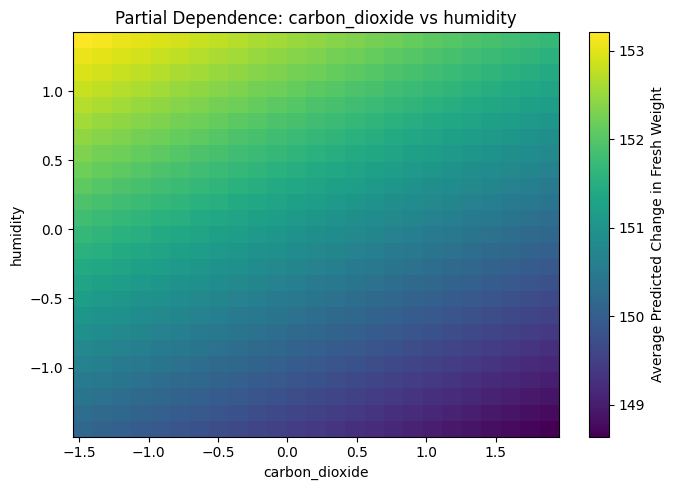

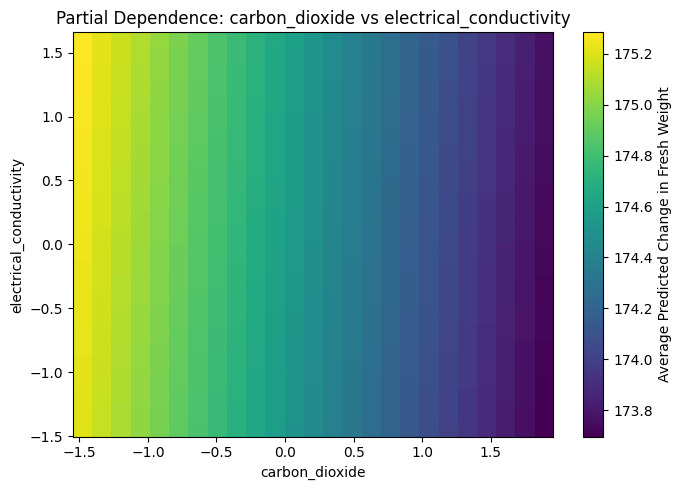

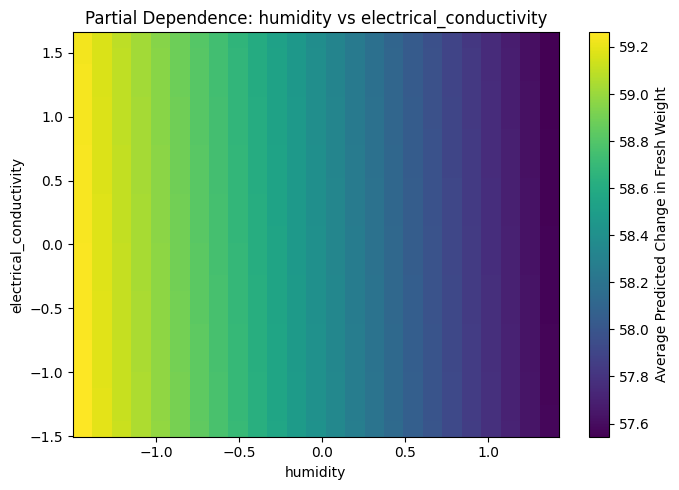

In [63]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# make sure model is in eval mode
model4.eval()

# feature pairs to examine
feature_pairs = [
    ("carbon_dioxide", "humidity"),
    ("carbon_dioxide", "electrical_conductivity"),
    ("humidity", "electrical_conductivity")
]

# map feature names to column indices
name_to_idx = {name: i for i, name in enumerate(feature_names)}

# use the ORIGINAL unscaled training data to define realistic value ranges
# and use the SCALED test tensor as the base data that gets modified
X_reference = X_test_tensor.clone()

grid_size = 25

for feat1, feat2 in feature_pairs:
    idx1 = name_to_idx[feat1]
    idx2 = name_to_idx[feat2]
    
    # grid in original feature units
    vals1_raw = np.linspace(X_train[:, idx1].min(), X_train[:, idx1].max(), grid_size)
    vals2_raw = np.linspace(X_train[:, idx2].min(), X_train[:, idx2].max(), grid_size)
    
    pdp = np.zeros((grid_size, grid_size))
    
    for i, v1_raw in enumerate(vals1_raw):
        for j, v2_raw in enumerate(vals2_raw):
            X_temp = X_reference.clone()
            
            # standardize using the fitted scaler from final model training
            v1_scaled = (v1_raw - scaler.mean_[idx1]) / scaler.scale_[idx1]
            v2_scaled = (v2_raw - scaler.mean_[idx2]) / scaler.scale_[idx2]
            
            X_temp[:, idx1] = v1_scaled
            X_temp[:, idx2] = v2_scaled
            
            with torch.no_grad():
                preds = model4(X_temp).cpu().numpy()
            
            pdp[j, i] = preds.mean()
    
    plt.figure(figsize=(7, 5))
    plt.imshow(
        pdp,
        origin="lower",
        aspect="auto",
        extent=[vals1_raw.min(), vals1_raw.max(), vals2_raw.min(), vals2_raw.max()]
    )
    plt.colorbar(label="Average Predicted Change in Fresh Weight")
    plt.xlabel(feat1)
    plt.ylabel(feat2)
    plt.title(f"Partial Dependence: {feat1} vs {feat2}")
    plt.tight_layout()
    plt.savefig(f"../Figures/pdp_{feat1}_{feat2}.png", bbox_inches="tight")
    plt.show()

# Neural Network Training [ARCHIVE]

In [35]:
import os, random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

set_seed(42)

Epoch [1/1000], Train Loss: 16153.4268, Val Loss: 23700.3926
Epoch [2/1000], Train Loss: 16149.4111, Val Loss: 23695.0703
Epoch [3/1000], Train Loss: 16145.4170, Val Loss: 23689.8184
Epoch [4/1000], Train Loss: 16141.4424, Val Loss: 23684.6035
Epoch [5/1000], Train Loss: 16137.4717, Val Loss: 23679.4238
Epoch [6/1000], Train Loss: 16133.4951, Val Loss: 23674.2285
Epoch [7/1000], Train Loss: 16129.5029, Val Loss: 23669.0254
Epoch [8/1000], Train Loss: 16125.5117, Val Loss: 23663.8457
Epoch [9/1000], Train Loss: 16121.5156, Val Loss: 23658.7090
Epoch [10/1000], Train Loss: 16117.5244, Val Loss: 23653.4844
Epoch [11/1000], Train Loss: 16113.5312, Val Loss: 23648.2578
Epoch [12/1000], Train Loss: 16109.5391, Val Loss: 23643.0469
Epoch [13/1000], Train Loss: 16105.5596, Val Loss: 23637.8184
Epoch [14/1000], Train Loss: 16101.5732, Val Loss: 23632.5527
Epoch [15/1000], Train Loss: 16097.5820, Val Loss: 23627.2480
Epoch [16/1000], Train Loss: 16093.5791, Val Loss: 23621.9121
Epoch [17/1000], 

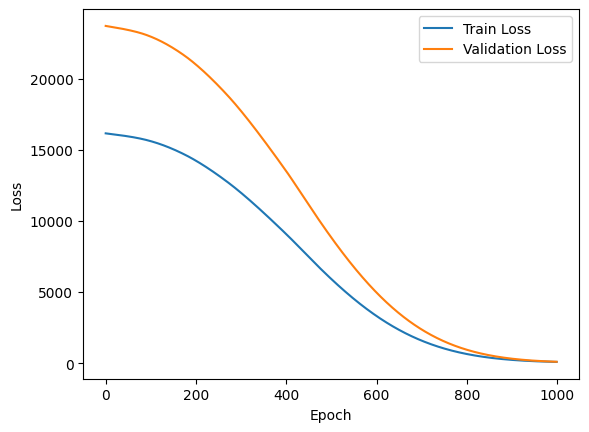

In [36]:
#ARCHIVE THIS ATER - ORIGINAL CODE OF NN

# load data 

import torch


df = (pd.read_csv('../Data/modeling_data.csv')
      )

target_col = 'total_fresh_weight_g'

X = df.drop(columns=[target_col]).to_numpy(dtype=np.float32)
y = df[target_col].to_numpy(dtype=np.float32).reshape(-1, 1)

feature_names = df.drop(columns=[target_col]).columns.tolist()


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# standardize 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

# convert to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)


#### Neural Network Model
class BasicNN(nn.Module): # inherits from Module
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__() # call initialization from module
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x
    
# pick manual seed
torch.manual_seed(42)

# hyperparameters    
input_size = X_train_tensor.shape[1]
hidden_size = 32
output_size = 1
learning_rate = .001
num_epochs = 1000

# initialize model
model = BasicNN(input_size=input_size, hidden_size=hidden_size, output_size=output_size)

# loss function
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)


# train
train_losses = []
val_losses = []

for epoch in range(num_epochs):

    ### training
    model.train()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    optimizer.zero_grad() 
    loss.backward() # compute gradients
    optimizer.step() # update weights

    train_losses.append(loss.item())

    ### validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_test_tensor)
        val_loss = criterion(val_outputs, y_test_tensor)

    val_losses.append(val_loss.item())

    print(f"Epoch [{epoch+1}/{num_epochs}], "
            f"Train Loss: {loss.item():.4f}, "
         f"Val Loss: {val_loss.item():.4f}")
    
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")


plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
# save figure
plt.savefig('../Figures/training_validation_loss.png')
plt.show()

In [37]:
df

,total_fresh_weight_g,carbon_dioxide,temp_env,humidity,pressure,electrical_conductivity,volume,temp_nutr,volume_flow_rate,weight_lag_1,weight_lag_2
0,40.1,514.051020,22.520816,65.247347,99282.511633,1521.816327,11551.277959,25.308837,1.087551,33.1,29.1
1,43.4,514.051020,22.520816,65.247347,99282.511633,1521.816327,11551.277959,25.308837,1.087551,36.3,30.1
2,43.6,514.051020,22.520816,65.247347,99282.511633,1521.816327,11551.277959,25.308837,1.087551,36.5,29.8
3,44.3,514.051020,22.520816,65.247347,99282.511633,1521.816327,11551.277959,25.308837,1.087551,38.1,29.7
4,45.0,514.051020,22.520816,65.247347,99282.511633,1521.816327,11551.277959,25.308837,1.087551,40.1,33.1
5,45.1,514.051020,22.520816,65.247347,99282.511633,1521.816327,11551.277959,25.308837,1.087551,38.5,30.2
6,46.0,514.051020,22.520816,65.247347,99282.511633,1521.816327,11551.277959,25.308837,1.087551,39.2,29.3
7,46.2,514.051020,22.520816,65.247347,99282.511633,1521.816327,11551.277959,25.308837,1.087551,39.2,30.4
8,46.8,514.051020,22.520816,65.247347,99282.511633,1521.816327,11551.277959,25.308837,1.087551,36.9,29.6
9,49.2,514.051020,22.520816,65.247347,99282.511633,1521.816327,11551.277959,25.308837,1.087551,42.1,31.8


## Permutation Importance

Baseline RMSE: 10.351102

Permutation results (20-repeat average):
electrical_conductivity    RMSE=27.4403  (Δ=+17.0892,  sd=2.6749)
volume_flow_rate           RMSE=27.4002  (Δ=+17.0491,  sd=3.5086)
weight_lag_1               RMSE=27.2577  (Δ=+16.9066,  sd=3.1153)
temp_nutr                  RMSE=26.3365  (Δ=+15.9854,  sd=4.1457)
weight_lag_2               RMSE=24.2349  (Δ=+13.8838,  sd=2.4228)
volume                     RMSE=23.8278  (Δ=+13.4767,  sd=3.5889)
humidity                   RMSE=23.5083  (Δ=+13.1572,  sd=3.1101)
pressure                   RMSE=20.5875  (Δ=+10.2364,  sd=3.1687)
temp_env                   RMSE=18.7953  (Δ=+8.4442,  sd=2.7443)
carbon_dioxide             RMSE=16.9412  (Δ=+6.5901,  sd=2.4942)


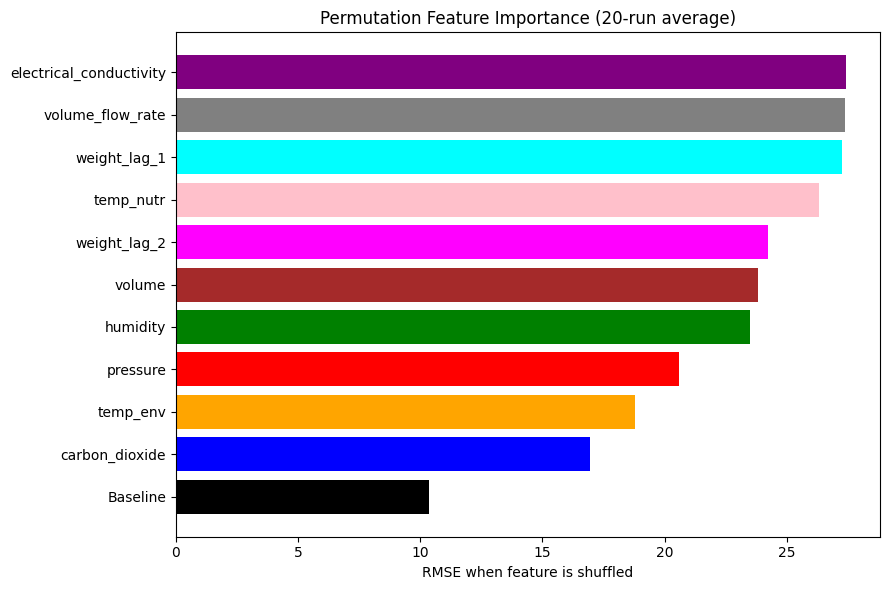

In [42]:
import numpy as np
import torch
import random
import matplotlib.pyplot as plt

# ==============================
# Set random seeds
# ==============================
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# ==============================
# RMSE function
# ==============================
def rmse(y_pred, y_true):
    return np.sqrt(np.mean((y_pred - y_true) ** 2))

model.eval()

# ==============================
# Baseline RMSE
# ==============================
with torch.no_grad():
    base_preds = model(X_test_tensor).cpu().numpy()

y_true = y_test_tensor.cpu().numpy()
base_rmse = rmse(base_preds, y_true)

# ==============================
# Permutation Importance (20 repeats)
# ==============================
repeats = 20
perm_results = []

X_test_base = X_test_tensor.clone()
N = X_test_base.shape[0]

for j, name in enumerate(feature_names):
    rmses = []

    for r in range(repeats):
        X_perm = X_test_base.clone()

        # shuffle feature j
        idx = torch.randperm(N)
        X_perm[:, j] = X_perm[idx, j]

        with torch.no_grad():
            preds = model(X_perm).cpu().numpy()

        rmses.append(rmse(preds, y_true))

    avg_perm_rmse = np.mean(rmses)
    std_perm_rmse = np.std(rmses)

    perm_results.append((name, avg_perm_rmse, std_perm_rmse))

# Sort by average permuted RMSE (largest first)
perm_results.sort(key=lambda x: x[1], reverse=True)

# ==============================
# Print results
# ==============================
print("Baseline RMSE:", round(base_rmse, 6))
print("\nPermutation results (20-repeat average):")

for name, avg_rmse, std_rmse in perm_results:
    delta = avg_rmse - base_rmse
    print(f"{name:25s}  RMSE={avg_rmse:.4f}  (Δ={delta:+.4f},  sd={std_rmse:.4f})")

# ==============================
# Plot
# ==============================

coef_colors = {
    'carbon_dioxide': 'blue',
    'temp_env': 'orange',
    'humidity': 'green',
    'pressure': 'red',
    'electrical_conductivity': 'purple',
    'volume': 'brown',
    'temp_nutr': 'pink',
    'volume_flow_rate': 'gray',
    'weight_lag_1': 'cyan',
    'weight_lag_2': 'magenta'
}

baseline_color = "black"

names = [n for n, _, _ in perm_results]
rmses = [r for _, r, _ in perm_results]
colors = [coef_colors.get(name, 'black') for name in names]

# Add baseline as separate bar
names_plot = names + ["Baseline"]
rmses_plot = rmses + [base_rmse]
colors_plot = colors + [baseline_color]

plt.figure(figsize=(9, 6))
plt.barh(names_plot[::-1], rmses_plot[::-1], color=colors_plot[::-1])

plt.xlabel("RMSE when feature is shuffled")
plt.title("Permutation Feature Importance (20-run average)")
plt.tight_layout()

plt.savefig('../Figures/permutation_importance.png', bbox_inches='tight')
plt.show()

shows importance for automation per var


## Sensitivity (Perturbation) analysis 


In [43]:
# baseline predictions

# fucntion that returns list of predictions after feature perturbation
def get_perturbed_predictions(model, X_test_tensor, feature_name, perturbation=0.1):
    with torch.no_grad():
        baseline_preds = model(X_test_tensor)

        X_perturbed = X_test_tensor.clone()
        X_perturbed[:, feature_names.index(feature_name)] *= (1 + perturbation)

        perturbed_preds = model(X_perturbed)

    return baseline_preds, perturbed_preds


get_perturbed_predictions(model, X_test_tensor, 'electrical_conductivity', perturbation=0.1)


perturbation_results = []

for feature in feature_names:

    baseline_preds, perturbed_plus_10 = get_perturbed_predictions(
        model, X_test_tensor, feature, perturbation=0.1
    )

    _, perturbed_minus_10 = get_perturbed_predictions(
        model, X_test_tensor, feature, perturbation=-0.1
    )

    _, perturbed_plus_20 = get_perturbed_predictions(
        model, X_test_tensor, feature, perturbation=0.2
    )

    _, perturbed_minus_20 = get_perturbed_predictions(
        model, X_test_tensor, feature, perturbation=-0.2
    )

    _, perturbed_plus_50 = get_perturbed_predictions(
        model, X_test_tensor, feature, perturbation=0.5
    )

    _, perturbed_minus_50 = get_perturbed_predictions(
        model, X_test_tensor, feature, perturbation=-0.5
    )

    _, perturbed_plus_80 = get_perturbed_predictions(
        model, X_test_tensor, feature, perturbation=0.8
    )

    _, perturbed_minus_80 = get_perturbed_predictions(
        model, X_test_tensor, feature, perturbation=-0.8
    )

    plus_10_effect = (perturbed_plus_10 - baseline_preds).mean().item()
    minus_10_effect = (perturbed_minus_10 - baseline_preds).mean().item()
    plus_20_effect = (perturbed_plus_20 - baseline_preds).mean().item()
    minus_20_effect = (perturbed_minus_20 - baseline_preds).mean().item()
    plus_50_effect = (perturbed_plus_50 - baseline_preds).mean().item()
    minus_50_effect = (perturbed_minus_50 - baseline_preds).mean().item()
    plus_80_effect = (perturbed_plus_80 - baseline_preds).mean().item()
    minus_80_effect = (perturbed_minus_80 - baseline_preds).mean().item()

    perturbation_results.append({
        "feature": feature,
        "+10% effect (g)": plus_10_effect,
        "-10% effect (g)": minus_10_effect,
        "+20% effect (g)": plus_20_effect,
        "-20% effect (g)": minus_20_effect,
        "+50% effect (g)": plus_50_effect,
        "-50% effect (g)": minus_50_effect,
        "+80% effect (g)": plus_80_effect,
        "-80% effect (g)": minus_80_effect
    })

perturbation_df = pd.DataFrame(perturbation_results)

perturbation_df = perturbation_df.sort_values(
    by="+10% effect (g)",
    key=lambda x: x.abs(),
    ascending=False
).reset_index(drop=True)

perturbation_df = perturbation_df.round(4)

perturbation_df


,feature,+10% effect (g),-10% effect (g),+20% effect (g),-20% effect (g),+50% effect (g),-50% effect (g),+80% effect (g),-80% effect (g)
0,electrical_conductivity,1.6130,-1.6090,3.2596,-3.2180,8.2459,-8.0454,13.2819,-12.8506
1,weight_lag_1,1.5398,-1.5368,3.0914,-3.0737,7.7882,-7.6851,12.5271,-12.2957
2,volume,1.4389,-1.4389,2.8818,-2.8779,7.2263,-7.1948,11.5719,-11.5017
3,temp_nutr,1.3222,-1.3207,2.6529,-2.6417,6.6591,-6.6048,10.6643,-10.5573
4,weight_lag_2,1.2799,-1.2800,2.5639,-2.5600,6.4585,-6.4013,10.3725,-10.2468
5,pressure,1.1519,-1.1520,2.3038,-2.3044,5.7586,-5.7443,9.2136,-9.1644
6,humidity,1.1003,-1.1003,2.2005,-2.2007,5.5008,-5.5004,8.8007,-8.7971
7,volume_flow_rate,0.9838,-0.9841,1.9676,-1.9684,4.9221,-4.9214,7.8815,-7.8744
8,temp_env,0.4902,-0.4648,0.9805,-0.9107,2.5955,-2.0982,4.6627,-3.2504
9,carbon_dioxide,0.4727,-0.4728,0.9449,-0.9429,2.3610,-2.2684,3.7770,-3.4676


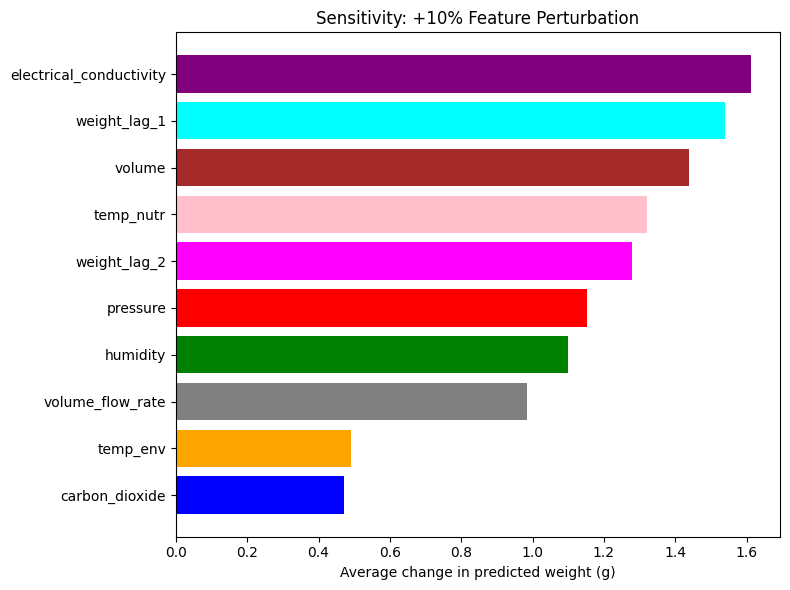

In [44]:
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt

# map feature colors
colors = perturbation_df["feature"].map(coef_colors)

plt.figure(figsize=(8,6))

plt.barh(
    perturbation_df["feature"],
    perturbation_df["+10% effect (g)"],
    color=colors
)

plt.xlabel("Average change in predicted weight (g)")
plt.title("Sensitivity: +10% Feature Perturbation")

plt.gca().invert_yaxis()  # most important feature at top

plt.tight_layout()
plt.show()

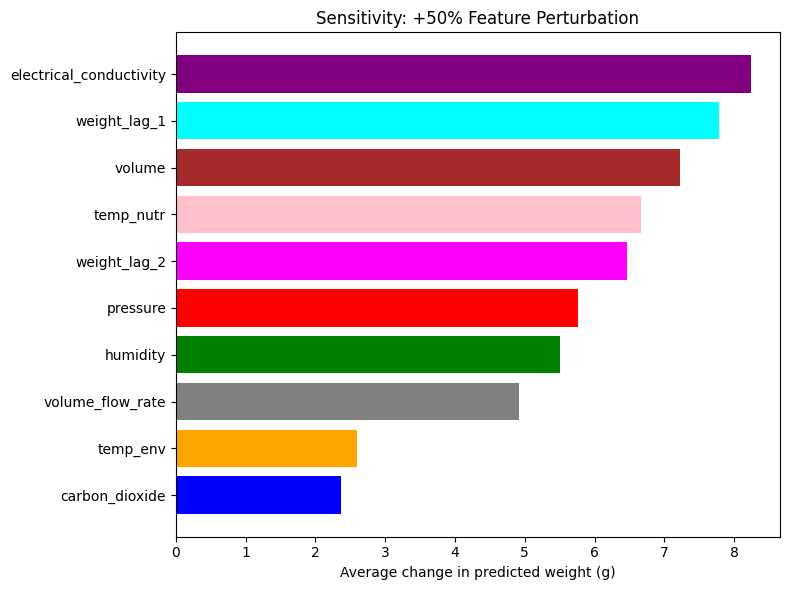

In [45]:
import matplotlib.pyplot as plt

# map feature colors
colors = perturbation_df["feature"].map(coef_colors)

plt.figure(figsize=(8,6))

plt.barh(
    perturbation_df["feature"],
    perturbation_df["+50% effect (g)"],
    color=colors
)

plt.xlabel("Average change in predicted weight (g)")
plt.title("Sensitivity: +50% Feature Perturbation")

plt.gca().invert_yaxis()  # most important feature at top

plt.tight_layout()
plt.show()

In [46]:
feature_names

['carbon_dioxide',
 'temp_env',
 'humidity',
 'pressure',
 'electrical_conductivity',
 'volume',
 'temp_nutr',
 'volume_flow_rate',
 'weight_lag_1',
 'weight_lag_2']

## 

# Interaction sensitivity analysis 

for example, increasing two features by 10 percent and observing the changes in model's predictions.

# SHAP ANALYSIS
* What is shap?
* How to use it?
* What insights can we gain from it?
* How can it inform our feature selection and model improvement efforts?
* What are the limitations of SHAP 
* How can we visualize SHAP values to better understand feature importance and interactions in our model?

/Users/gerardogutierrez/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 12/12 [00:00<00:00, 40.64it/s]
/var/folders/b2/dv4s0x994dz37s4d7fv56q8r0000gn/T/ipykernel_52636/712915484.py:56: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


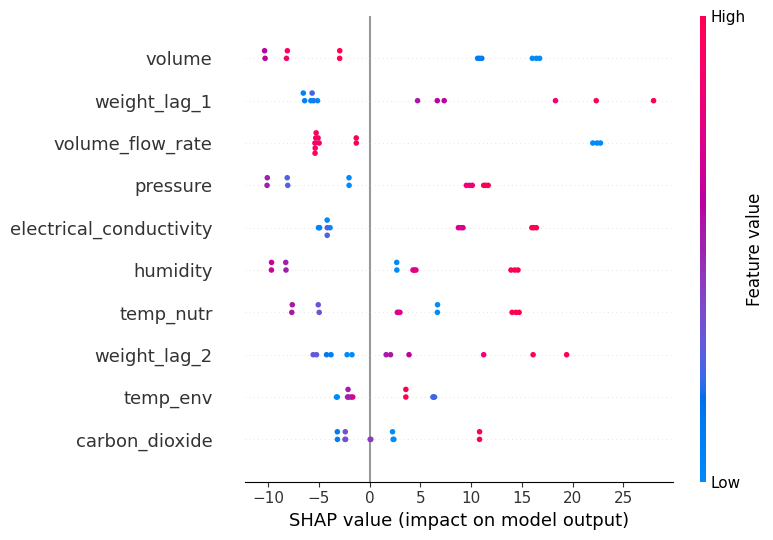

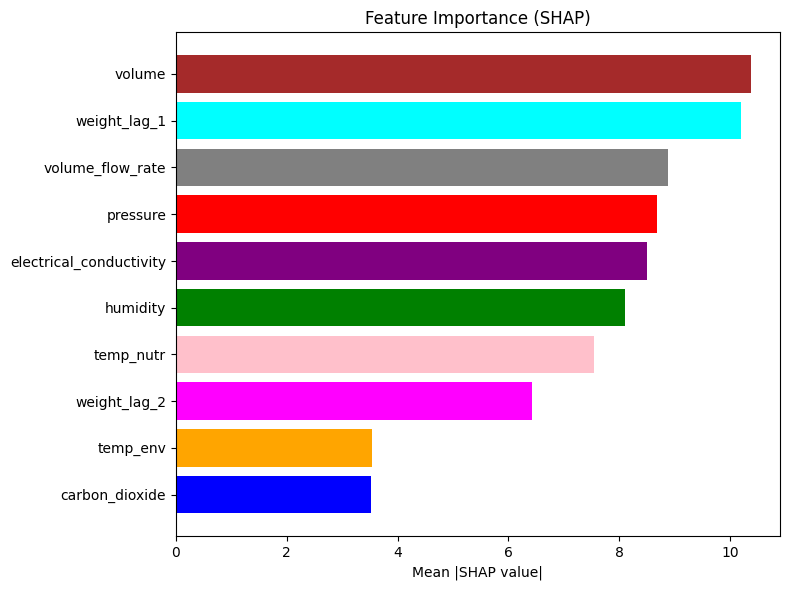

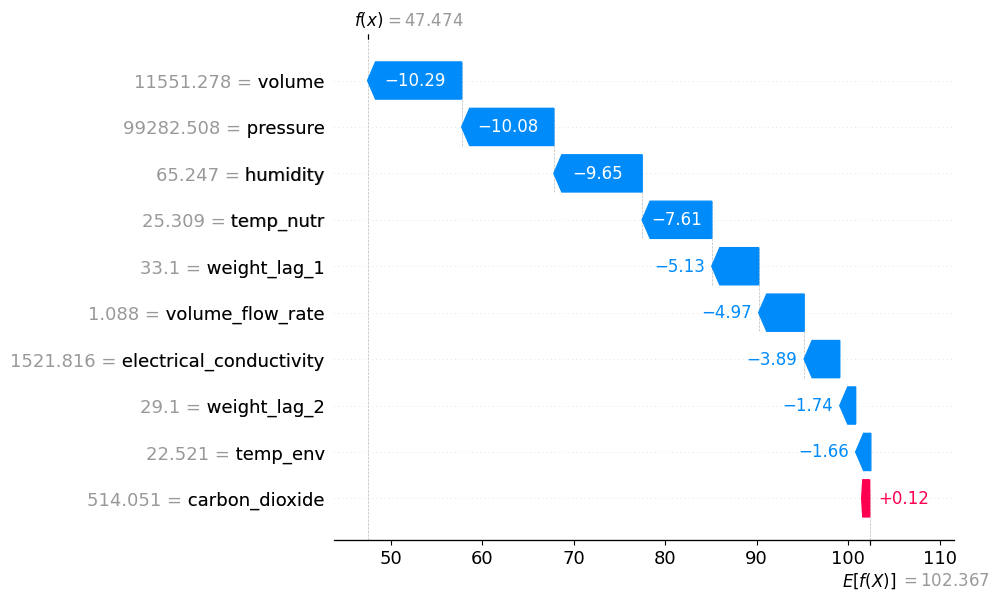

<Figure size 640x480 with 0 Axes>

Features ranked by mean |SHAP|:
- volume
- weight_lag_1
- volume_flow_rate
- pressure
- electrical_conductivity
- humidity
- temp_nutr
- weight_lag_2
- temp_env
- carbon_dioxide


<Figure size 640x480 with 0 Axes>

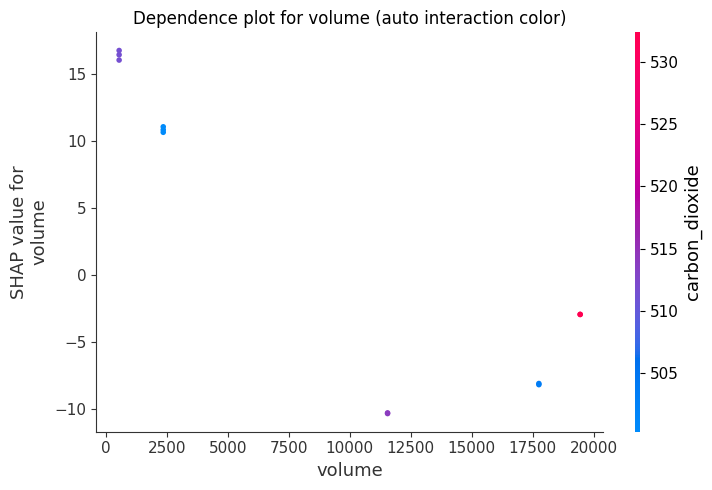

<Figure size 640x480 with 0 Axes>

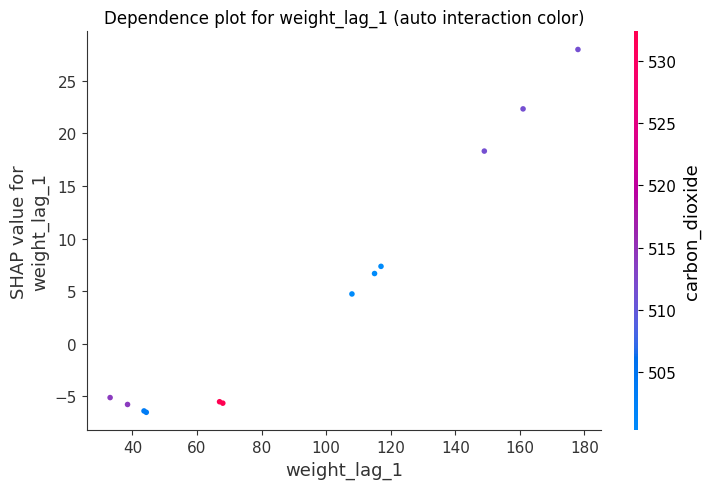

<Figure size 640x480 with 0 Axes>

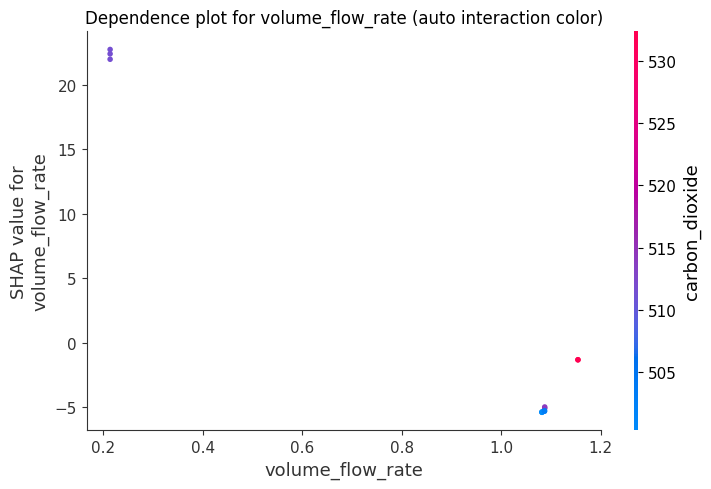

<Figure size 640x480 with 0 Axes>

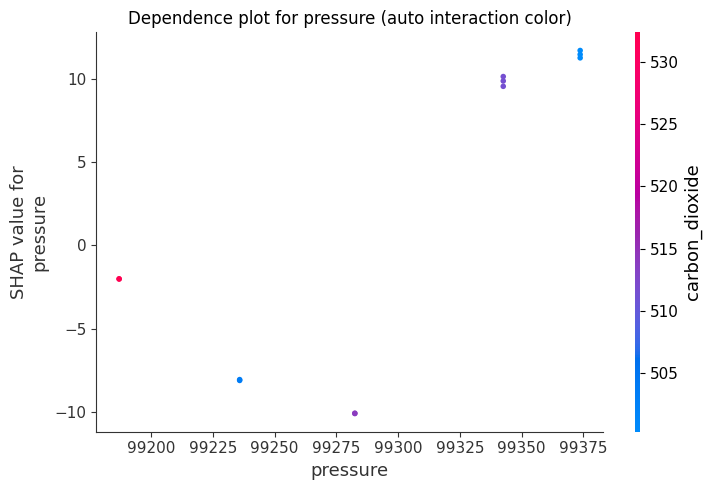

<Figure size 640x480 with 0 Axes>

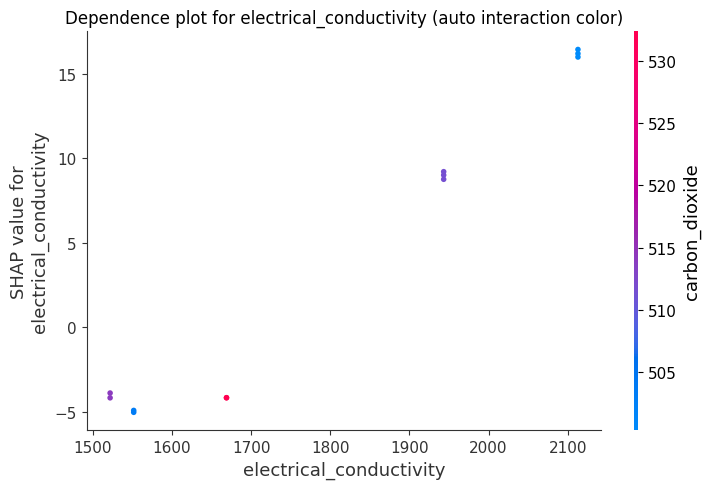

<Figure size 640x480 with 0 Axes>

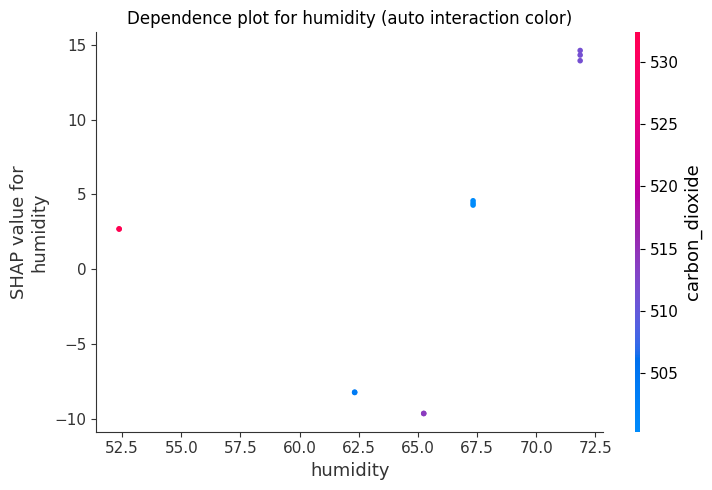

<Figure size 640x480 with 0 Axes>

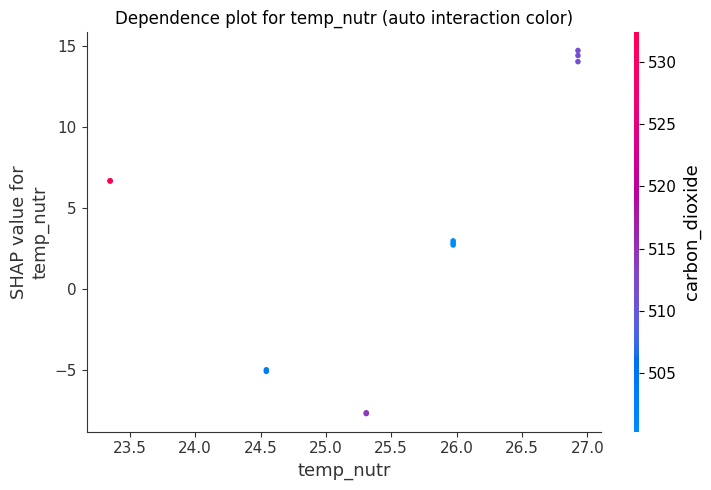

<Figure size 640x480 with 0 Axes>

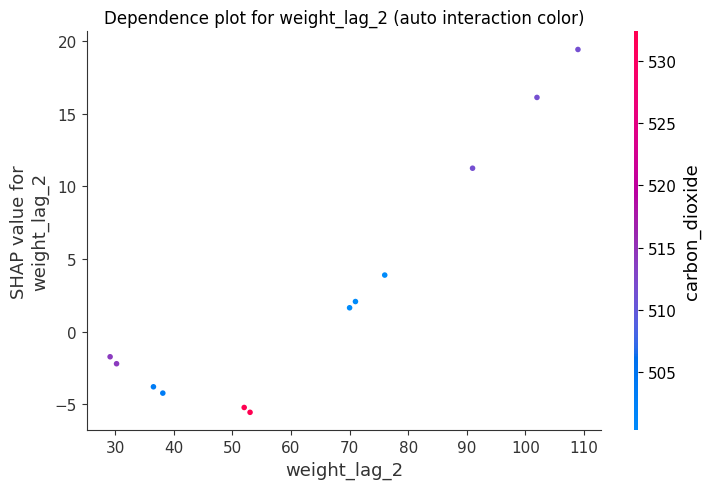

<Figure size 640x480 with 0 Axes>

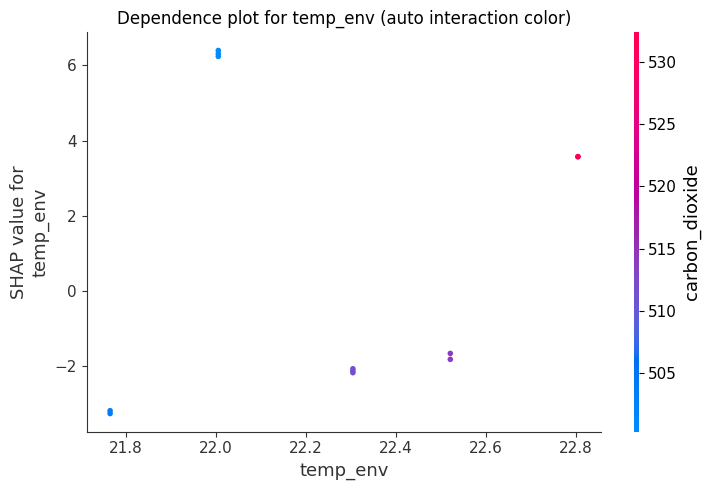

<Figure size 640x480 with 0 Axes>

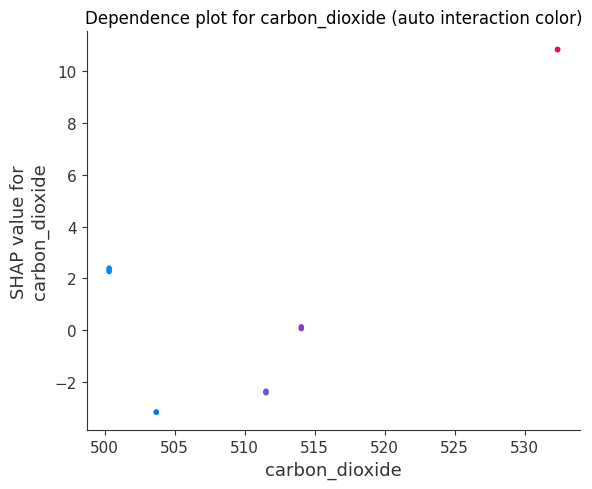

Selected features for pairwise interaction plots:
- electrical_conductivity
- volume_flow_rate
- temp_nutr
- humidity


<Figure size 700x500 with 0 Axes>

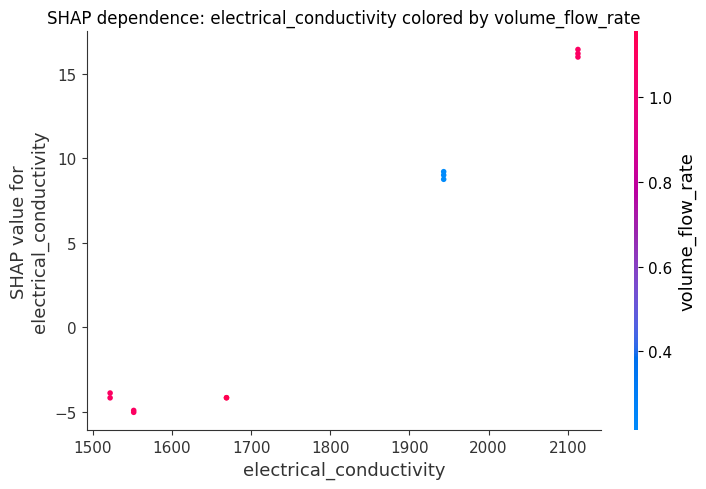

<Figure size 700x500 with 0 Axes>

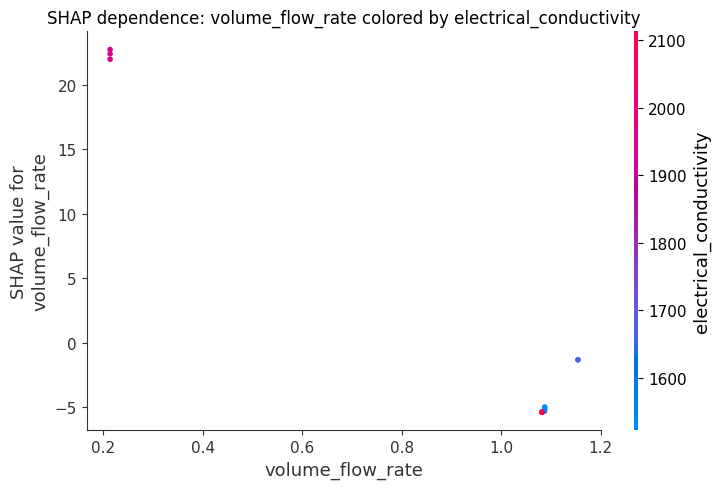

<Figure size 700x500 with 0 Axes>

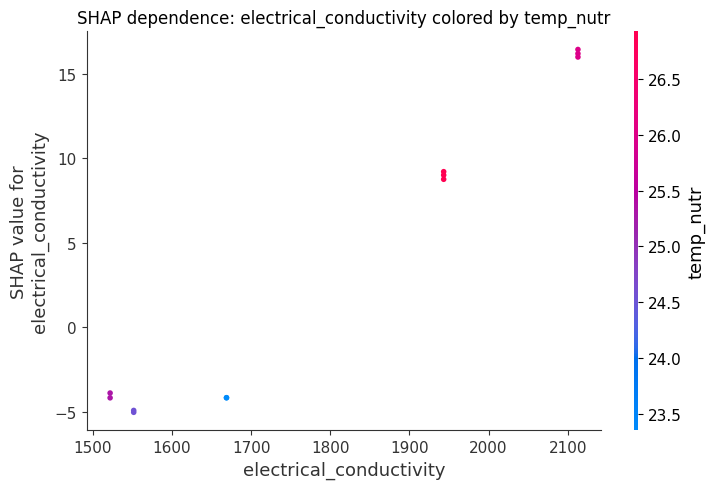

<Figure size 700x500 with 0 Axes>

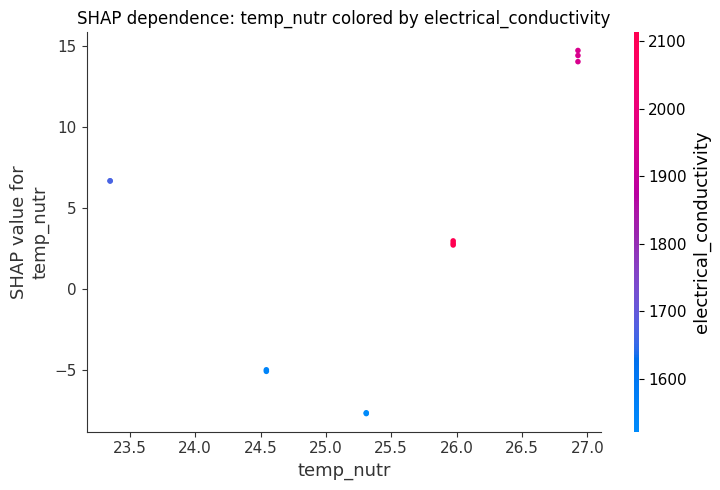

<Figure size 700x500 with 0 Axes>

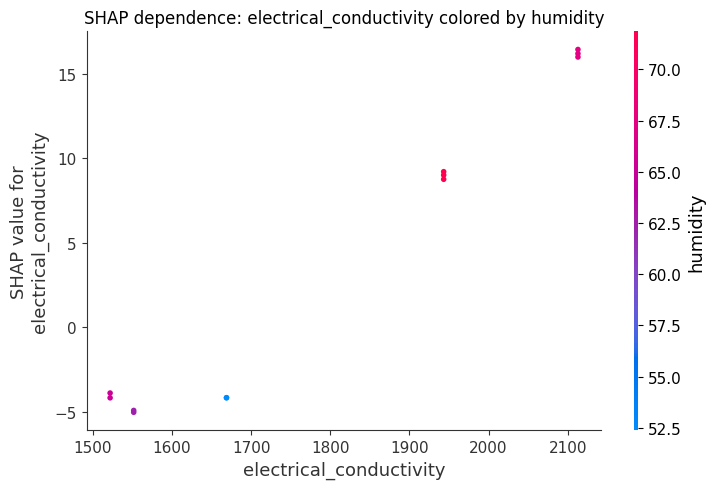

<Figure size 700x500 with 0 Axes>

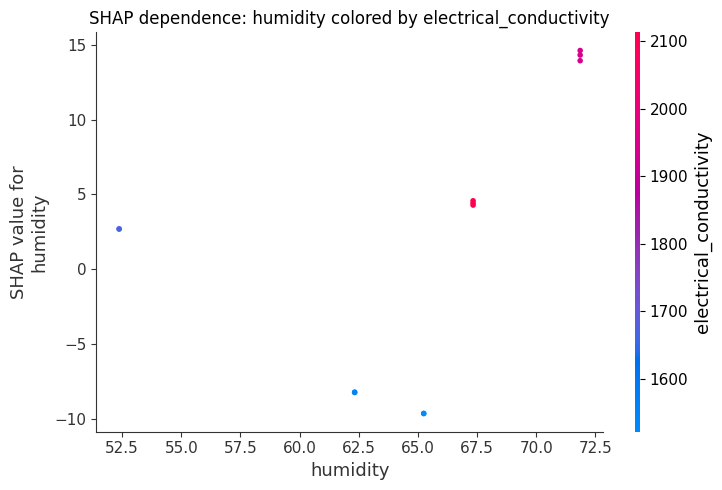

<Figure size 700x500 with 0 Axes>

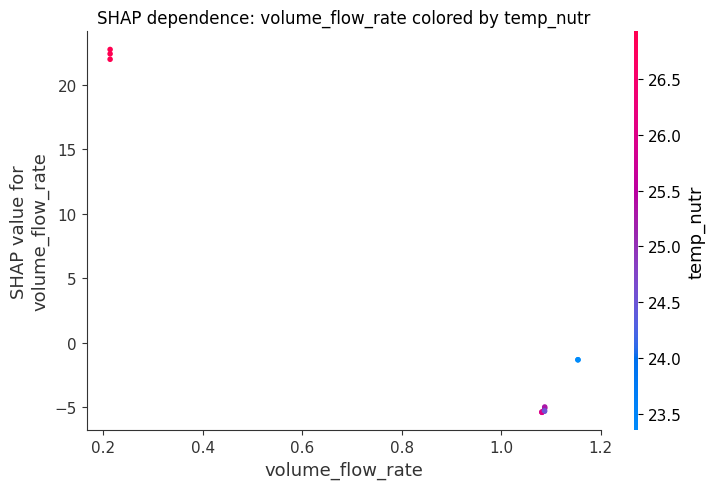

<Figure size 700x500 with 0 Axes>

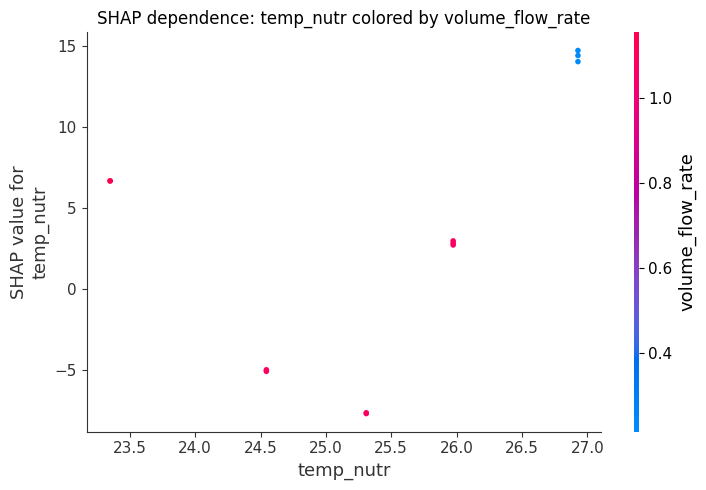

<Figure size 700x500 with 0 Axes>

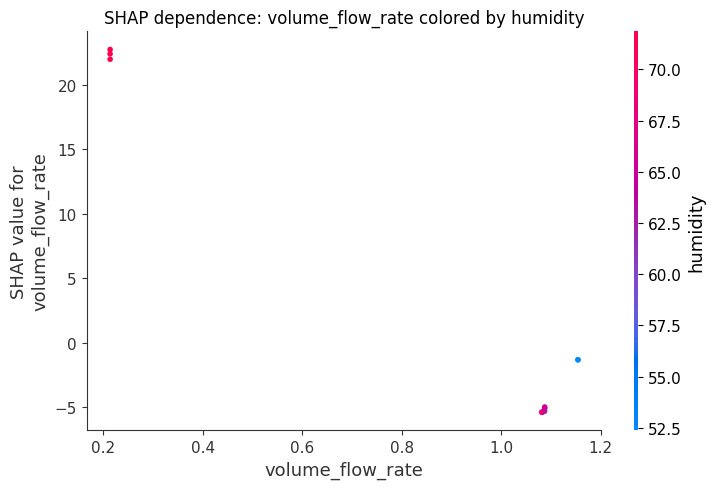

<Figure size 700x500 with 0 Axes>

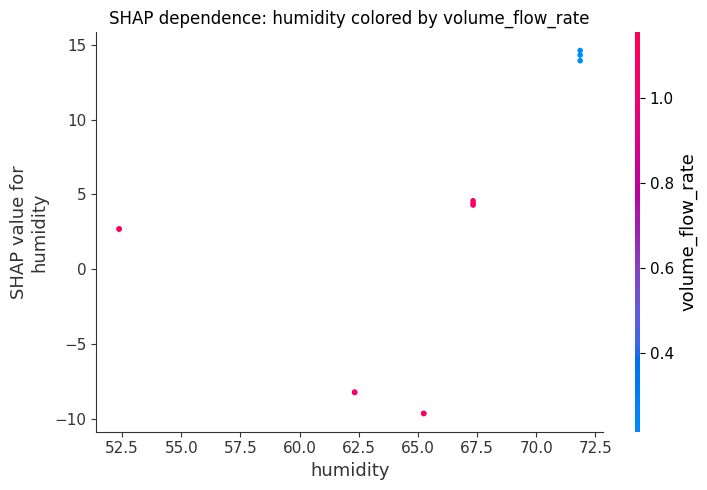

<Figure size 700x500 with 0 Axes>

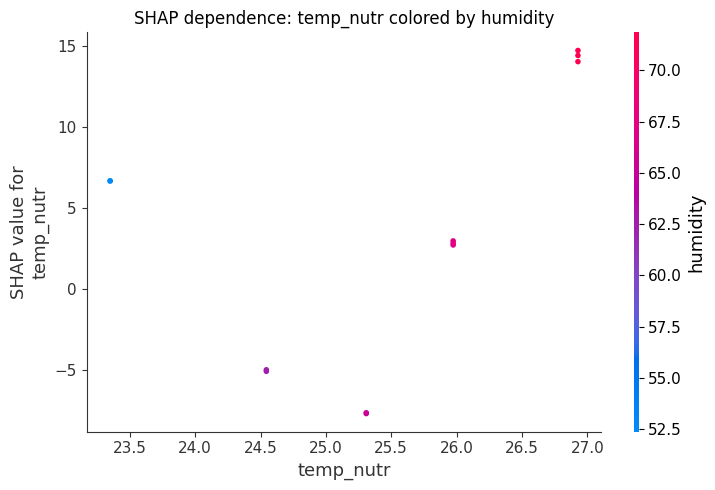

<Figure size 700x500 with 0 Axes>

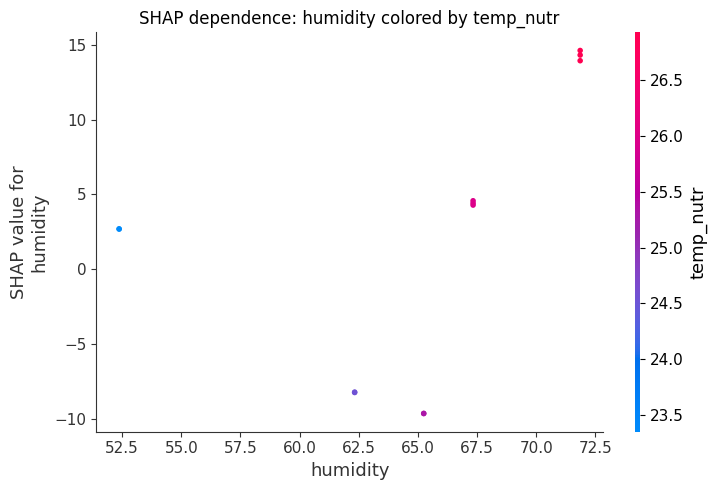


Global SHAP importance table:


,feature,mean_abs_shap,mean_shap
0,volume,10.3791,3.2455
1,weight_lag_1,10.1984,4.3622
2,volume_flow_rate,8.8730,2.3170
3,pressure,8.6881,1.9567
4,electrical_conductivity,8.4942,4.0992
5,humidity,8.1066,2.1378
6,temp_nutr,7.5355,3.3204
7,weight_lag_2,6.4268,2.6312
8,temp_env,3.5300,0.8188
9,carbon_dioxide,3.5280,1.2759


In [47]:
import numpy as np
import pandas as pd
import torch
import shap
import matplotlib.pyplot as plt
import itertools

# -----------------------------
# Keep raw versions for SHAP display
# -----------------------------
X_train_raw = df.drop(columns=[target_col]).to_numpy(dtype=np.float32)
y_raw = df[target_col].to_numpy(dtype=np.float32).reshape(-1, 1)

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_train_raw, y_raw, test_size=0.2, random_state=42
)

# -----------------------------
# SHAP prediction wrapper
# Takes RAW input -> scales it -> predicts with trained model
# -----------------------------
def model_predict_raw(x):
    x = np.array(x, dtype=np.float32)
    x_scaled = scaler.transform(x).astype(np.float32)
    x_tensor = torch.tensor(x_scaled, dtype=torch.float32)

    model.eval()
    with torch.no_grad():
        preds = model(x_tensor).cpu().numpy().reshape(-1)

    return preds

# -----------------------------
# Background data
# With your small dataset, using all training data is fine
# -----------------------------
background = X_train_raw

# -----------------------------
# Kernel SHAP explainer
# -----------------------------
explainer = shap.KernelExplainer(model_predict_raw, background)

# Explain the test set
# If this is slow, replace X_test_raw with X_test_raw[:10]
shap_values = explainer.shap_values(X_test_raw)

# Convert to numpy array if needed
shap_values = np.array(shap_values)

# -----------------------------
# 1) Summary plot (main global plot)
# Shows feature importance + direction of effect
# -----------------------------
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_raw,
    feature_names=feature_names,
    show=False
)
plt.tight_layout()
# save figure
plt.savefig('../Figures/NN_shap_summary_plot.png', bbox_inches='tight')
plt.show()
    
# -----------------------------
# 2) Bar plot
# Shows mean absolute SHAP value (global importance only)
# -----------------------------
mean_abs_shap = np.abs(shap_values).mean(axis=0)

# Create DataFrame for sorting
bar_df = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=True)

# Map colors using your predefined dictionary
bar_colors = [coef_colors.get(f, "gray") for f in bar_df["feature"]]

plt.figure(figsize=(8, 6))
plt.barh(bar_df["feature"], bar_df["mean_abs_shap"], color=bar_colors)
plt.xlabel("Mean |SHAP value|")
plt.title("Feature Importance (SHAP)")
plt.tight_layout()
plt.savefig('../Figures/NN_shap_bar_plot.png', bbox_inches='tight')
plt.show()

# -----------------------------
# 3) Waterfall plot for one sample
# Shows how each feature contributed to one prediction
# -----------------------------
sample_idx = 0

# Expected value may be scalar or array depending on SHAP version
expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)):
    expected_value = np.array(expected_value).reshape(-1)[0]

explanation = shap.Explanation(
    values=shap_values[sample_idx],
    base_values=expected_value,
    data=X_test_raw[sample_idx],
    feature_names=feature_names
)

shap.plots.waterfall(explanation, max_display=10)
plt.savefig('../Figures/NN_shap_waterfall_plot.png', bbox_inches='tight')
plt.show()

# -----------------------------
# 4) Automatic dependence plots
# x-axis = feature value
# y-axis = SHAP value for that feature
# color = automatically chosen interacting feature
# -----------------------------
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_feature_idx = np.argsort(mean_abs_shap)[::-1]
top_features = [feature_names[i] for i in top_feature_idx]

print("Features ranked by mean |SHAP|:")
for f in top_features:
    print("-", f)

# automatic coloring for all features
for f in top_features:
    plt.figure()
    shap.dependence_plot(
        f,
        shap_values,
        X_test_raw,
        feature_names=feature_names,
        show=False
    )
    plt.title(f"Dependence plot for {f} (auto interaction color)")
    plt.tight_layout()
    plt.show()

# -----------------------------
# 5) Pairwise interaction-style dependence plots
# x-axis = feature A
# y-axis = SHAP value for feature A
# color = feature B
# -----------------------------

# -------------------------------------------------
# Pairwise SHAP dependence plots for selected features
# -------------------------------------------------
selected_features = [
    "electrical_conductivity",
    "volume_flow_rate",
    "temp_nutr",
    "humidity"
]

# safety check
missing = [f for f in selected_features if f not in feature_names]
if missing:
    raise ValueError(f"These selected features are missing from feature_names: {missing}")

print("Selected features for pairwise interaction plots:")
for f in selected_features:
    print("-", f)

# For each unordered pair, make BOTH directional plots:
#   1) SHAP(feature A) colored by feature B
#   2) SHAP(feature B) colored by feature A
for f1, f2 in itertools.combinations(selected_features, 2):
    
    # Plot 1: effect of f1, colored by f2
    plt.figure(figsize=(7, 5))
    shap.dependence_plot(
        f1,
        shap_values,
        X_test_raw,
        interaction_index=f2,
        feature_names=feature_names,
        show=False
    )
    plt.title(f"SHAP dependence: {f1} colored by {f2}")
    plt.tight_layout()
    plt.show()

    # Plot 2: effect of f2, colored by f1
    plt.figure(figsize=(7, 5))
    shap.dependence_plot(
        f2,
        shap_values,
        X_test_raw,
        interaction_index=f1,
        feature_names=feature_names,
        show=False
    )
    plt.title(f"SHAP dependence: {f2} colored by {f1}")
    plt.tight_layout()
    plt.show()   

# -----------------------------
# 6) SHAP importance table
# -----------------------------
shap_importance_df = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
    "mean_shap": shap_values.mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

print("\nGlobal SHAP importance table:")
display(shap_importance_df.round(4))

# Ablation study 

REMOVING FEATURE: carbon_dioxide
Feature removed: carbon_dioxide
RMSE: 11.1713


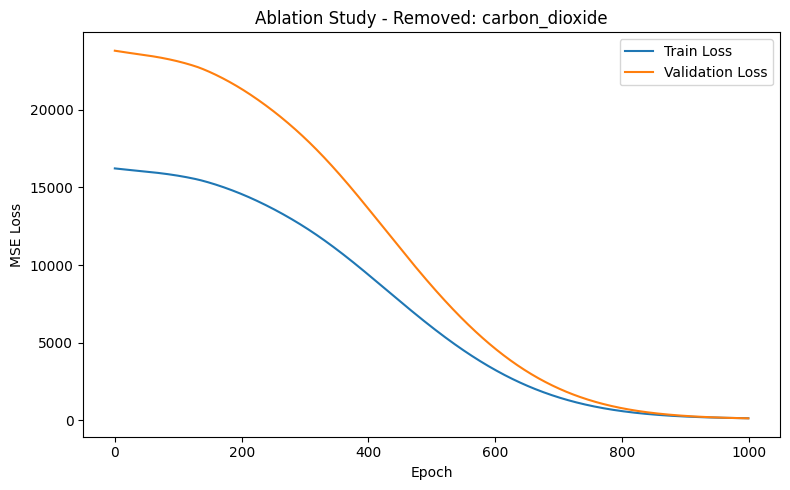

REMOVING FEATURE: temp_env
Feature removed: temp_env
RMSE: 15.1467


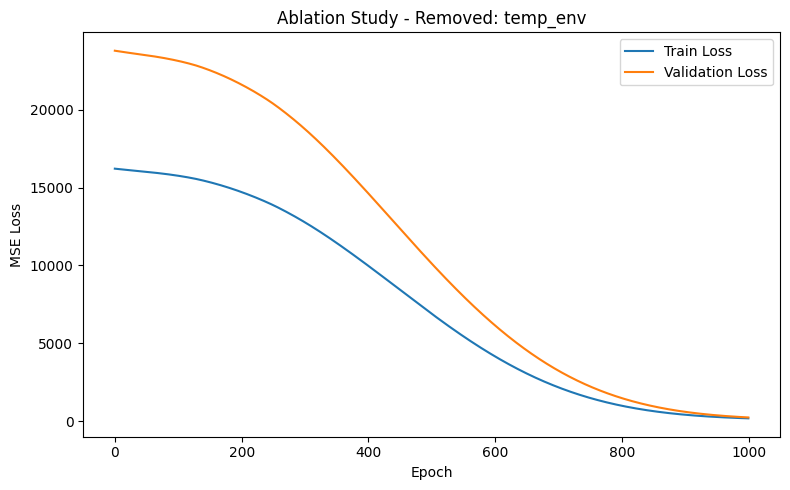

REMOVING FEATURE: humidity
Feature removed: humidity
RMSE: 12.1438


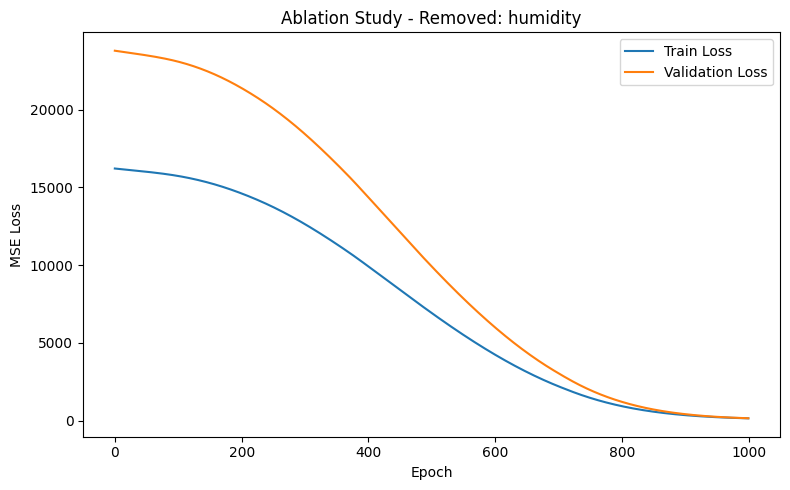

REMOVING FEATURE: pressure
Feature removed: pressure
RMSE: 14.1742


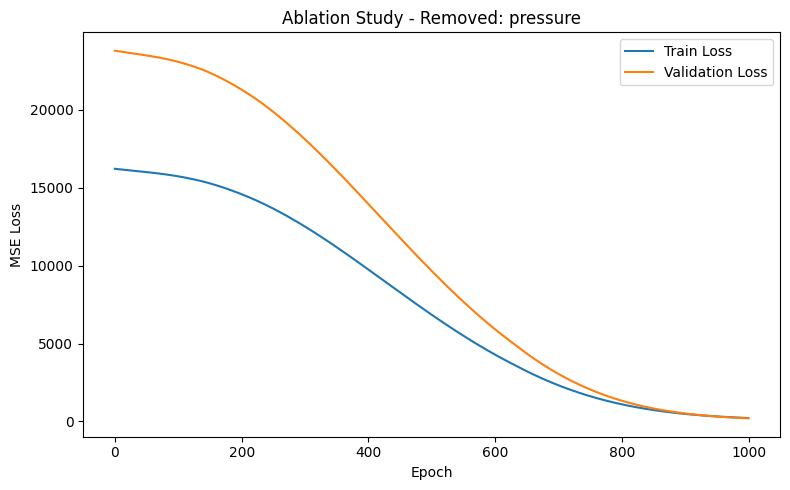

REMOVING FEATURE: electrical_conductivity
Feature removed: electrical_conductivity
RMSE: 13.3740


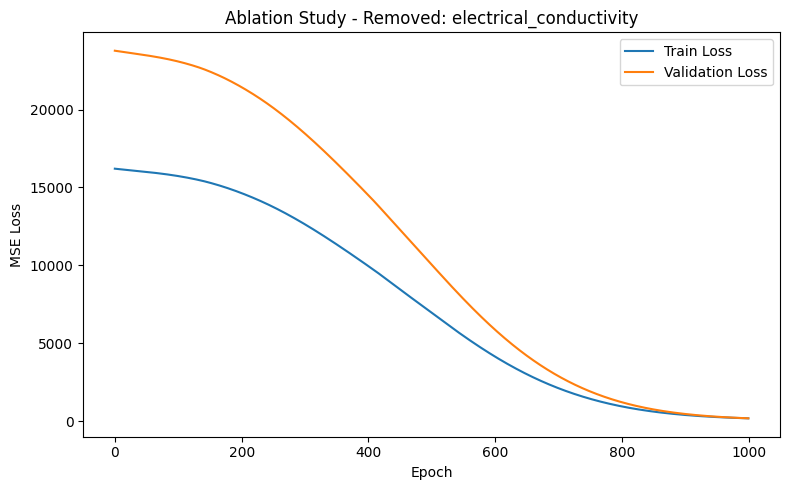

REMOVING FEATURE: volume
Feature removed: volume
RMSE: 13.5410


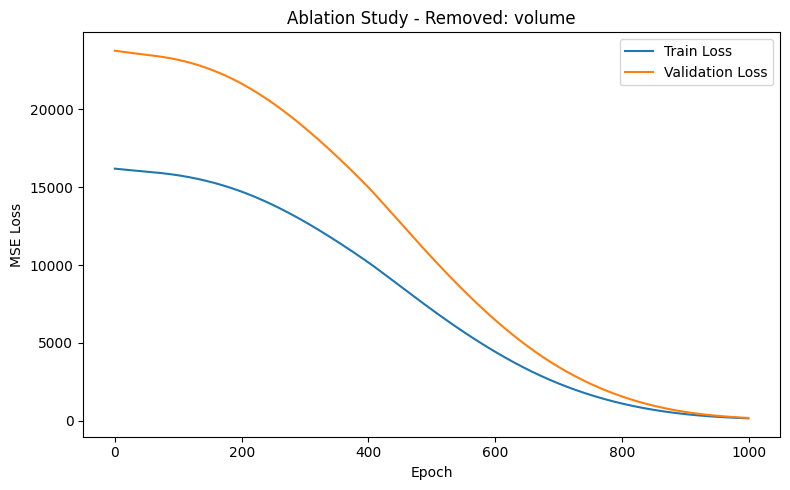

REMOVING FEATURE: temp_nutr
Feature removed: temp_nutr
RMSE: 15.5705


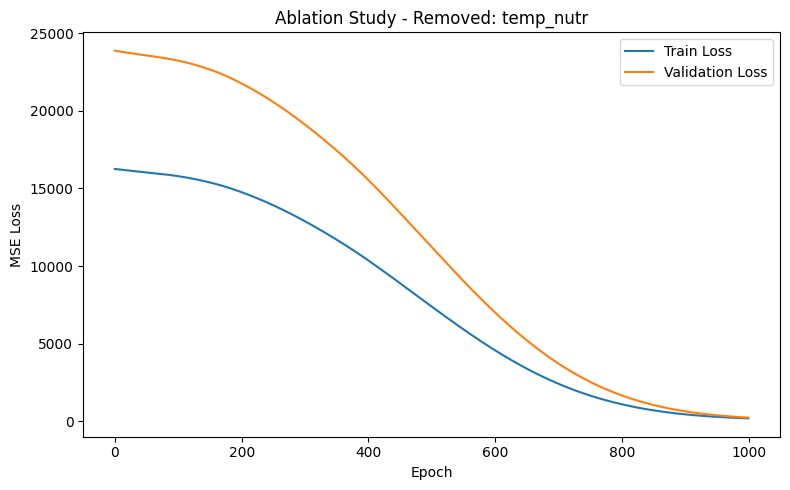

REMOVING FEATURE: volume_flow_rate
Feature removed: volume_flow_rate
RMSE: 16.2626


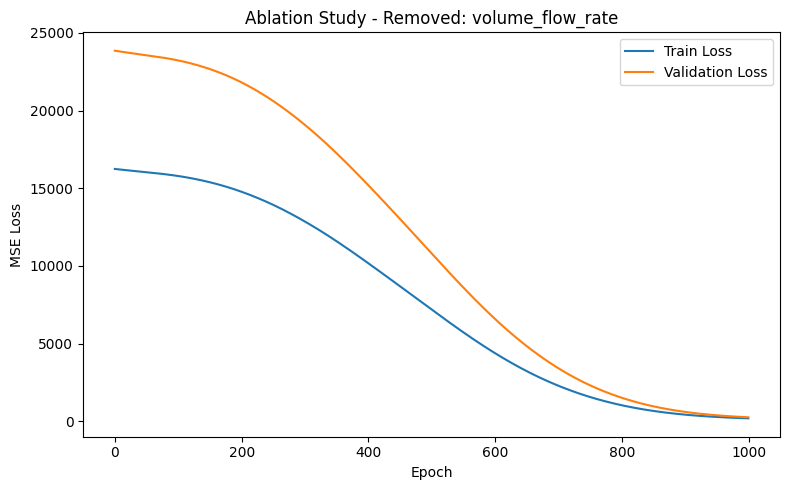

REMOVING FEATURE: weight_lag_1
Feature removed: weight_lag_1
RMSE: 13.0554


KeyboardInterrupt: 

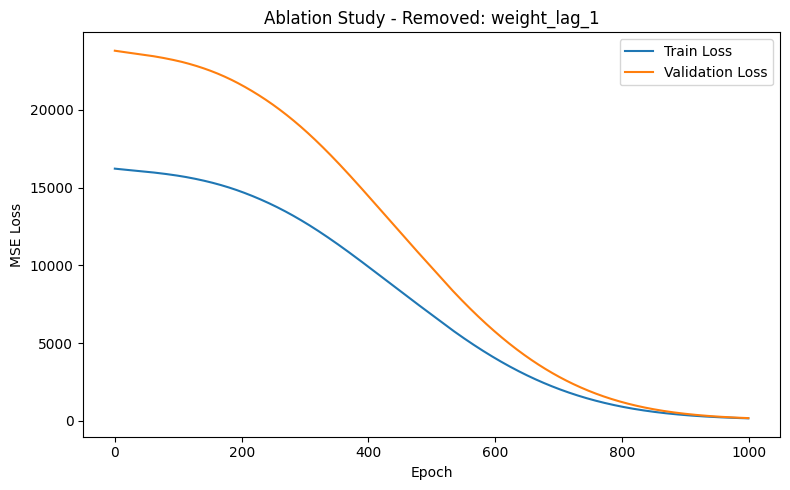

In [48]:
# === Ablation study: remove one feature at a time, retrain, plot losses, print RMSE ===

import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error


# -----------------------------
# Reproducibility
# -----------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(42)


# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv('../Data/modeling_data.csv')

target_col = 'total_fresh_weight_g'
all_features = df.drop(columns=[target_col]).columns.tolist()


# -----------------------------
# Model
# -----------------------------
class BasicNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x


# -----------------------------
# Same hyperparameters/settings
# -----------------------------
hidden_size = 32
output_size = 1
learning_rate = 0.001
num_epochs = 1000


# -----------------------------
# Store ablation results
# -----------------------------
ablation_results = []


# -----------------------------
# Loop through each feature removal
# -----------------------------
for feature_removed in all_features:
    print("=" * 80)
    print(f"REMOVING FEATURE: {feature_removed}")

    # 
    kept_features = [f for f in all_features if f != feature_removed]

    X = df[kept_features].to_numpy(dtype=np.float32)
    y = df[target_col].to_numpy(dtype=np.float32).reshape(-1, 1)

    # 
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # s
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train).astype(np.float32)
    X_test = scaler.transform(X_test).astype(np.float32)

    # tensors
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

    # re-seed before each model so runs are comparable
    set_seed(42)

    # fresh model each time
    input_size = X_train_tensor.shape[1]
    model = BasicNN(input_size=input_size, hidden_size=hidden_size, output_size=output_size)

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    train_losses = []
    val_losses = []

    # train
    for epoch in range(num_epochs):
        model.train()
        outputs = model(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_outputs = model(X_test_tensor)
            val_loss = criterion(val_outputs, y_test_tensor)

        val_losses.append(val_loss.item())

    # final predictions + RMSE
    model.eval()
    with torch.no_grad():
        final_preds = model(X_test_tensor).numpy()

    rmse = np.sqrt(mean_squared_error(y_test, final_preds))

    print(f"Feature removed: {feature_removed}")
    print(f"RMSE: {rmse:.4f}")

    ablation_results.append({
        "feature_removed": feature_removed,
        "rmse": rmse
    })

    # plot losses for this ablation run
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title(f"Ablation Study - Removed: {feature_removed}")
    plt.legend()
    plt.tight_layout()

    # optional save
    safe_name = feature_removed.replace("/", "_")
    plt.savefig(f"../Figures/ablation_removed_{safe_name}.png")
    plt.show()


# -----------------------------
# Final summary dataframe
# -----------------------------
ablation_df = pd.DataFrame(ablation_results).sort_values("rmse", ascending=False).reset_index(drop=True)

print("\nAblation study summary:")
print(ablation_df)

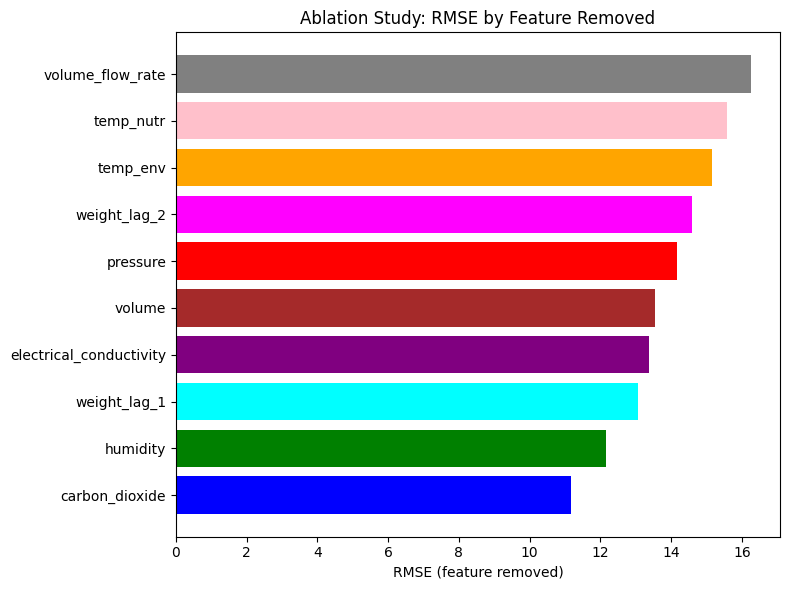

In [ ]:
# === Plot RMSE for each feature removed 

colors = ablation_df["feature_removed"].map(coef_colors)

plt.figure(figsize=(8,6))

plt.barh(
    ablation_df["feature_removed"],
    ablation_df["rmse"],
    color=colors
)

plt.xlabel("RMSE (feature removed)")
plt.title("Ablation Study: RMSE by Feature Removed")

plt.gca().invert_yaxis()  # highest RMSE at top

plt.tight_layout()
plt.savefig("../Figures/ablation_rmse_by_feature.png")
plt.show()